# Underwater Acoustic Classifier ( Not with the STM Configuration )
**Hierarchical pipeline:** Non-Threat Family Classifier → (extensible to Threat stage)

**Classes:** Background | Beluga | Dolphin | Narwhal | Seal | Vessel | Walrus | Whale | **Torpedo** | **Submarine**

**Audio config:** 22 kHz SR · 2.0 s clips · 64-mel · AmplitudeToDB

## 1 · Imports & Configuration

In [1]:
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# ── Audio preprocessing config ──────────────────────────────
@dataclass
class AudioConfig:
    sample_rate: int   = 22_050   # standard for acoustic ML; resample everything
    duration_ms: float = 2_000    # 2 seconds — enough for vessel/bio signatures
    n_fft: int         = 1_024
    hop_length: int    = 512
    n_mels: int        = 64
    top_db: int        = 80

    @property
    def max_samples(self) -> int:
        return int(self.sample_rate * self.duration_ms / 1000)   ## 44100

    @property
    def expected_frames(self) -> int:
        return 1 + (self.max_samples - self.n_fft) // self.hop_length  # 84 frame

CFG = AudioConfig()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'Samples: {CFG.max_samples}  |  Expected frames: {CFG.expected_frames}')

Device : cuda
Samples: 44100  |  Expected frames: 85


In [2]:
from google.cloud import storage
from google.cloud.storage import transfer_manager


# Function to Download Data from Google Cloud 
def list_and_download_NOAA_Dataset(bucket_name, site_prefix, destination_directory="", max_results=5 ):
    
    # 1. Setup Anonymous Client
    storage_client = storage.Client.create_anonymous_client()
    bucket = storage_client.bucket(bucket_name)

    print(f"🔎 Probing bucket: {bucket_name}")
    print(f"   Looking inside: {site_prefix}")

    blobs = list(bucket.list_blobs(prefix=site_prefix, max_results=max_results))

    # 4. Download specific files 
    print("\n ================== Starting downloading files ==================")

    # Only get the names for the transfer manager
    blob_names = [b.name for b in blobs]

    results = transfer_manager.download_many_to_path(
        bucket, blob_names, destination_directory=destination_directory, max_workers=4
    )


#  CONFIGURATION 

# Data location in the bucket
target_prefix = "sanctsound/products/sound_clips"

list_and_download_NOAA_Dataset(
    bucket_name="noaa-passive-bioacoustic",
    site_prefix=target_prefix,
    destination_directory="sanctsound",
    max_results = 300
)

🔎 Probing bucket: noaa-passive-bioacoustic
   Looking inside: sanctsound/products/sound_clips

 ================== Starting downloading files ==================


## 2 · Data Loading

In [3]:
# ── Family mapping ───────────────────────────────────────────
WHALE_SPECIES = [
    'Humpback Whale', 'Sperm Whale', 'Bowhead Whale',
    'Fin_ Finback Whale', 'Minke Whale', 'Killer Whale',
    'Northern Right Whale', 'Southern Right Whale',
    'Long-Finned Pilot Whale', 'Short-Finned _Pacific_ Pilot Whale',
    'Melon Headed Whale', 'False Killer Whale'
]
DOLPHIN_SPECIES = [
    'Spinner Dolphin', 'Fraser_s Dolphin', 'Striped Dolphin',
    'Pantropical Spotted Dolphin', 'Atlantic Spotted Dolphin',
    'Common Dolphin', 'Bottlenose Dolphin', 'Clymene Dolphin',
    'Rough-Toothed Dolphin', 'Grampus_ Risso_s Dolphin',
    'White-beaked Dolphin', 'White-sided Dolphin'
]
SEAL_SPECIES   = ['Ross Seal', 'Harp Seal', 'Bearded Seal', 'Leopard Seal', 'Weddell Seal']
VESSEL_TYPES   = ['Small vessels', 'Medium vessels', 'Large vessels', 'Passenger ferries']

def assign_family(class_name: str) -> str:
    if class_name in WHALE_SPECIES:   return 'Whale'
    if class_name in DOLPHIN_SPECIES: return 'Dolphin'
    if class_name in SEAL_SPECIES:    return 'Seal'
    if class_name in VESSEL_TYPES:    return 'Vessel'
    mapping = {
        'Beluga_ White Whale': 'Beluga',
        'Narwhal':             'Narwhal',
        'Walrus':              'Walrus',
        'Background Noise':    'Background',
        # ── NEW THREAT CLASSES ──
        'Torpedo':             'Torpedo',
        'Submarine':           'Submarine',
    }
    return mapping.get(class_name, 'Unknown')


# ── Loaders ──────────────────────────────────────────────────
def load_ds3500(data_path: str) -> pd.DataFrame:
    """DS3500 vessel + background dataset."""
    label_map = {0: 'Small vessels', 1: 'Medium vessels',
                 2: 'Passenger ferries', 3: 'Large vessels', 4: 'Background Noise'}
    files = sorted(f for f in os.listdir(data_path) if f.endswith('.wav'))
    df = pd.DataFrame(files, columns=['filename'])
    df['class'] = df['filename'].str[0].astype(int).map(label_map)
    df['path']  = df['filename'].apply(lambda x: os.path.join(data_path, x))
    return df[['path', 'class']]


def load_noaa(root: str) -> pd.DataFrame:
    """NOAA SanctSound — keep soundscape / rain / sonar as Background."""
    keep = {'soundscape', 'rain', 'sonar'}
    records = []
    for dirpath, _, filenames in os.walk(root):
        if os.path.basename(dirpath) != 'data':
            continue
        for f in filenames:
            if not f.endswith('.wav'):
                continue
            try:
                label = f.split('_')[3].lower()
            except IndexError:
                label = 'unknown'
            if label in keep:
                records.append({'path': os.path.join(dirpath, f),
                                'class': 'Background Noise'})
    return pd.DataFrame(records)


def load_watkins(root: str) -> pd.DataFrame:
    """Watkins Marine Mammal Sound Library."""
    records = []
    for dirpath, _, filenames in os.walk(root):
        species = os.path.basename(dirpath)
        for f in filenames:
            if f.endswith('.wav'):
                records.append({'path': os.path.join(dirpath, f), 'class': species})
    return pd.DataFrame(records)


import os
import pandas as pd

def load_threat_data(
    root_dir: str = None,
    torpedo_dir: str = None,
    submarine_dir: str = None
) -> pd.DataFrame:
    """
    Load torpedo / submarine WAV files from either:
      - a single folder (root_dir) where class is inferred from filename
      - or separate torpedo_dir and submarine_dir folders (legacy)

    In the root_dir mode, filenames must contain '_submarine' or '_torpedo'.
    Example: '000000_submarine.wav' -> class 'Submarine'.

    Returns a DataFrame with columns ['path', 'class'].
    """
    records = []

    # If root_dir is provided, scan that folder and infer class from filename
    if root_dir and os.path.isdir(root_dir):
        for f in os.listdir(root_dir):
            if f.endswith('.wav'):
                # Extract class from filename: e.g. "000000_submarine.wav"
                # We assume the class is the part before the extension after the last underscore.
                basename = os.path.splitext(f)[0]           # "000000_submarine"
                parts = basename.split('_')
                if len(parts) >= 2:
                    class_label = parts[-1].capitalize()    # "submarine" -> "Submarine"
                    # Validate known classes
                    if class_label in ['Submarine', 'Torpedo']:
                        records.append({
                            'path': os.path.join(root_dir, f),
                            'class': class_label
                        })
                    else:
                        print(f"[WARNING] Unknown class '{class_label}' in file {f}, skipping.")
                else:
                    print(f"[WARNING] Filename {f} does not contain underscore, skipping.")
        print(f"[INFO] Found {len(records)} files in {root_dir}.")

    # Fallback to explicit separate directories (if root_dir not given or empty)
    else:
        for label, path in [('Torpedo', torpedo_dir), ('Submarine', submarine_dir)]:
            if path and os.path.isdir(path):
                for f in os.listdir(path):
                    if f.endswith('.wav'):
                        records.append({'path': os.path.join(path, f), 'class': label})
                print(f"[INFO] Found {len([f for f in os.listdir(path) if f.endswith('.wav')])} files for {label}.")
            else:
                print(f'[INFO] No data path for {label} — class will be absent from training.')

    if not records:
        print("[WARNING] No data loaded. Returning empty DataFrame.")
        return pd.DataFrame(columns=['path', 'class'])

    return pd.DataFrame(records)


# ── Assemble full dataset ─────────────────────────────────────
DS3500_PATH  = '/kaggle/input/datasets/abdullahabdelaziz00/ds3500'
NOAA_ROOT    = '/kaggle/working/sanctsound/sanctsound/products/sound_clips'
WATKINS_ROOT = '/kaggle/input/datasets/abdullahabdelaziz00/watkins-marine-mammals-sound'
TORPEDO_DIR  = None   # e.g. '/kaggle/input/torpedo-sounds'
SUBMARINE_DIR= None   # e.g. '/kaggle/input/submarine-sounds'
THREAT_ROOT = '/kaggle/input/datasets/abdullahabdelaziz00/submarine-and-torpedo/audio'
df_vessel  = load_ds3500(DS3500_PATH)
df_noaa    = load_noaa(NOAA_ROOT)
df_marine  = load_watkins(WATKINS_ROOT)
df_threat  = load_threat_data(THREAT_ROOT, TORPEDO_DIR, SUBMARINE_DIR)

full_data = pd.concat([df_vessel, df_noaa, df_marine, df_threat], ignore_index=True)
full_data['family'] = full_data['class'].apply(assign_family)
full_data = full_data[full_data['family'] != 'Unknown'].copy()

print(f'Total samples : {len(full_data)}')
print('\nFamily distribution:')
print(full_data['family'].value_counts().to_string())

[INFO] Found 500 files in /kaggle/input/datasets/abdullahabdelaziz00/submarine-and-torpedo/audio.
Total samples : 4491

Family distribution:
family
Vessel        1999
Dolphin        774
Whale          639
Background     295
Submarine      250
Torpedo        250
Seal           146
Beluga          50
Narwhal         50
Walrus          38


## 3 · Spectrogram Precomputation & Dataset

In [4]:
def precompute_spectrograms(df: pd.DataFrame, save_dir: str, cfg: AudioConfig) -> pd.DataFrame:
    """Convert WAV files to mel-spectrograms and cache as .npy."""
    os.makedirs(save_dir, exist_ok=True)
    mel_transform = T.MelSpectrogram(
        sample_rate=cfg.sample_rate,
        n_fft=cfg.n_fft,
        hop_length=cfg.hop_length,
        n_mels=cfg.n_mels
    )
    db_transform = T.AmplitudeToDB(top_db=cfg.top_db)

    df = df.reset_index(drop=True).copy()
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f'Spectrograms → {save_dir}'):
        out_path = os.path.join(save_dir, f'{idx}.npy')
        if os.path.exists(out_path):   # resume-friendly
            continue
        try:
            sig, sr = torchaudio.load(row['path'])
            if sr != cfg.sample_rate:
                sig = T.Resample(sr, cfg.sample_rate)(sig)
            if sig.shape[0] > 1:
                sig = sig.mean(dim=0, keepdim=True)
            # Pad / trim
            n = cfg.max_samples
            if sig.shape[1] >= n:
                sig = sig[:, :n]
            else:
                sig = F.pad(sig, (0, n - sig.shape[1]))
            spec = db_transform(mel_transform(sig))
            np.save(out_path, spec.numpy())
        except Exception as e:
            print(f'[WARN] {row["path"]}: {e}')

    df['spec_path'] = [os.path.join(save_dir, f'{i}.npy') for i in df.index]
    return df


class AcousticDataset(Dataset):
    def __init__(self, df: pd.DataFrame, label_col: str = 'label', augment: bool = False):
        self.df       = df.reset_index(drop=True)
        self.label_col = label_col
        self.augment  = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        spec = torch.FloatTensor(np.load(row['spec_path']))
        if self.augment:
            if torch.rand(1) > 0.5:
                spec = T.TimeMasking(time_mask_param=10)(spec)
            if torch.rand(1) > 0.5:
                spec = T.FrequencyMasking(freq_mask_param=8)(spec)
        return spec, torch.tensor(row[self.label_col], dtype=torch.long)

## 4 · Model A — Strong Custom CNN

In [5]:
class ResBlock(nn.Module):
    """Residual block with squeeze-and-excitation."""
    def __init__(self, ch: int, dropout: float = 0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
        )
        # Squeeze-and-Excitation
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, ch // 4), nn.ReLU(inplace=True),
            nn.Linear(ch // 4, ch), nn.Sigmoid()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        h = self.conv(x)
        w = self.se(h).view(h.size(0), h.size(1), 1, 1)
        return F.relu(x + self.drop(h * w), inplace=True)


class AcousticCNN(nn.Module):
    """
    4-stage CNN with residual + SE blocks.
    Input : (B, 1, n_mels, T)
    """
    def __init__(self, num_classes: int, dropout_fc: float = 0.4):
        super().__init__()

        def stage(in_ch, out_ch, pool=True, drop=0.1):
            layers = [
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                ResBlock(out_ch, drop),
            ]
            if pool:
                layers.append(nn.MaxPool2d(kernel_size=(2, 1)))
            return nn.Sequential(*layers)

        self.encoder = nn.Sequential(
            stage(1,   32,  pool=True,  drop=0.05),
            stage(32,  64,  pool=True,  drop=0.10),
            stage(64,  128, pool=True,  drop=0.15),
            stage(128, 256, pool=False, drop=0.20),   # no pool on last stage
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(dropout_fc),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Dropout(dropout_fc * 0.75),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.head(self.gap(self.encoder(x)))


def count_params(model): return sum(p.numel() for p in model.parameters())

# Quick shape check
dummy = torch.randn(4, 1, CFG.n_mels, 4)   # 4 frames for testing
_m = AcousticCNN(num_classes=10)
print(f'AcousticCNN output: {_m(dummy).shape}  |  params: {count_params(_m):,}')
del _m, dummy

AcousticCNN output: torch.Size([4, 10])  |  params: 2,101,826


## 5 · Model B — Pretrained EfficientNet / ResNet

In [6]:
import torchvision.models as tv_models

class PretrainedAcoustic(nn.Module):
    """
    Unified wrapper for multiple torchvision backbones.
    Accepts single-channel mel-spectrogram input (B, 1, n_mels, T).
    
    Supported backbones:
        mobilenet_v3_small | mobilenet_v3_large
        efficientnet_b0    | efficientnet_b1
        resnet18           | resnet34
        squeezenet1_1
    """
    def __init__(self, num_classes: int, backbone_name: str, pretrained: bool = True):
        super().__init__()
        self.backbone_name = backbone_name
        weights = 'DEFAULT' if pretrained else None

        if backbone_name == 'mobilenet_v3_small':
            base = tv_models.mobilenet_v3_small(weights=weights)
            c1 = base.features[0][0]
            base.features[0][0] = nn.Conv2d(1, c1.out_channels, c1.kernel_size,
                                             c1.stride, c1.padding, bias=False)
            in_feat = base.classifier[3].in_features
            base.classifier[3] = nn.Identity()
            self.backbone = base

        elif backbone_name == 'mobilenet_v3_large':
            base = tv_models.mobilenet_v3_large(weights=weights)
            c1 = base.features[0][0]
            base.features[0][0] = nn.Conv2d(1, c1.out_channels, c1.kernel_size,
                                             c1.stride, c1.padding, bias=False)
            in_feat = base.classifier[3].in_features
            base.classifier[3] = nn.Identity()
            self.backbone = base

        elif backbone_name in ('efficientnet_b0', 'efficientnet_b1'):
            base = getattr(tv_models, backbone_name)(weights=weights)
            c1 = base.features[0][0]
            base.features[0][0] = nn.Conv2d(1, c1.out_channels, c1.kernel_size,
                                             c1.stride, c1.padding, bias=False)
            in_feat = base.classifier[1].in_features
            base.classifier = nn.Identity()
            self.backbone = base

        elif backbone_name in ('resnet18', 'resnet34'):
            base = getattr(tv_models, backbone_name)(weights=weights)
            c1 = base.conv1
            base.conv1 = nn.Conv2d(1, c1.out_channels, c1.kernel_size,
                                   c1.stride, c1.padding, bias=False)
            in_feat = base.fc.in_features
            base.fc = nn.Identity()
            self.backbone = base

        elif backbone_name == 'squeezenet1_1':
            base = tv_models.squeezenet1_1(weights=weights)
            c1 = base.features[0]
            base.features[0] = nn.Conv2d(1, c1.out_channels, c1.kernel_size,
                                         c1.stride, c1.padding, bias=False)
            # SqueezeNet classifier outputs num_classes directly — rebuild it
            base.classifier[1] = nn.Conv2d(512, 512, kernel_size=1)
            base.num_classes = 512
            in_feat = 512
            self.backbone = base

        else:
            raise ValueError(f'Unsupported backbone: {backbone_name}')

        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_feat, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True

    def forward(self, x):
        # All backbones need at least 32×32 spatial input
        if x.shape[-2] < 32 or x.shape[-1] < 32:
            x = F.interpolate(x, size=(max(32, x.shape[-2]), max(32, x.shape[-1])),
                              mode='bilinear', align_corners=False)

        feat = self.backbone(x)

        # SqueezeNet returns (B, 512, H, W) — needs global pooling
        if feat.dim() == 4:
            feat = feat.mean(dim=[2, 3])

        return self.head(feat)

## 6 · Training Engine

In [7]:
from torch.optim.lr_scheduler import CosineAnnealingLR

def run_epoch(model, loader, criterion, optimizer, device, train: bool):
    model.train() if train else model.eval()
    total_loss = total_correct = total = 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss    += loss.item()
            preds          = out.argmax(1)
            total_correct += (preds == y).sum().item()
            total         += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return {
        'loss': total_loss / len(loader),
        'acc':  total_correct / total,
        'f1':   f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'preds': all_preds, 'labels': all_labels
    }


def train(
    model, train_loader, val_loader, *,
    num_epochs=30, lr=1e-3, weight_decay=1e-4,
    patience=7, save_path='best_model.pth',
    # For pretrained two-phase training:
    warmup_epochs=0, warmup_lr=1e-3, finetune_lr=5e-5,
    device=DEVICE
):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    history  = {k: [] for k in ('train_loss','train_acc','val_loss','val_acc','val_f1')}
    best_f1  = 0.0
    no_improve = 0

    for epoch in range(1, num_epochs + 1):
        # Two-phase unfreeze for pretrained models
        if warmup_epochs and epoch == warmup_epochs + 1:
            print('  → Unfreezing backbone for fine-tuning')
            model.unfreeze_backbone()
            for pg in optimizer.param_groups:
                pg['lr'] = finetune_lr

        tr = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        vl = run_epoch(model, val_loader,   criterion, optimizer, device, train=False)
        scheduler.step()

        for k, v in [('train_loss', tr['loss']), ('train_acc', tr['acc']),
                     ('val_loss',   vl['loss']), ('val_acc',   vl['acc']),
                     ('val_f1',     vl['f1'])]:
            history[k].append(v)

        flag = ''
        if vl['f1'] > best_f1:
            best_f1 = vl['f1']
            no_improve = 0
            torch.save(model.state_dict(), save_path)
            flag = '  ✓ saved'
        else:
            no_improve += 1

        print(f'Ep {epoch:3d}/{num_epochs} | '
              f'Train {tr["loss"]:.4f}/{tr["acc"]:.4f} | '
              f'Val {vl["loss"]:.4f}/{vl["acc"]:.4f} F1={vl["f1"]:.4f}{flag}')

        if no_improve >= patience:
            print(f'Early stop at epoch {epoch}')
            break

        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    return history, vl['labels'], vl['preds']

## 7 · Data Preparation & Label Encoding

In [8]:
# ── Filter rare classes ───────────────────────────────────────
MIN_SAMPLES = 15
counts = full_data['family'].value_counts()
full_data = full_data[full_data['family'].isin(counts[counts >= MIN_SAMPLES].index)].copy()

# ── Encode ───────────────────────────────────────────────────
le = LabelEncoder()
full_data['label'] = le.fit_transform(full_data['family'])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# ── Stratified split ─────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(sss.split(full_data, full_data['label']))
train_df = full_data.iloc[train_idx].reset_index(drop=True)
val_df   = full_data.iloc[val_idx].reset_index(drop=True)
print(f'Train: {len(train_df)}  |  Val: {len(val_df)}')

# ── Precompute spectrograms ───────────────────────────────────
train_df = precompute_spectrograms(train_df, 'specs_train', CFG)
val_df   = precompute_spectrograms(val_df,   'specs_val',   CFG)

# ── DataLoaders ──────────────────────────────────────────────
BATCH = 32
train_loader = DataLoader(AcousticDataset(train_df, augment=True),
                          batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(AcousticDataset(val_df,   augment=False),
                          batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print('Dataloaders ready.')

Classes (10): ['Background', 'Beluga', 'Dolphin', 'Narwhal', 'Seal', 'Submarine', 'Torpedo', 'Vessel', 'Walrus', 'Whale']
Train: 3817  |  Val: 674


Spectrograms → specs_val: 100%|██████████| 674/674 [01:24<00:00,  7.96it/s]

Dataloaders ready.


## 8 · Train Model A — AcousticCNN

In [9]:
model_cnn = AcousticCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(f'AcousticCNN params: {count_params(model_cnn):,}')

history_cnn, labels_cnn, preds_cnn = train(
    model_cnn, train_loader, val_loader,
    num_epochs=40, lr=1e-3, patience=8,
    save_path='best_acoustic_cnn.pth'
)

# Load best weights for evaluation
model_cnn.load_state_dict(torch.load('best_acoustic_cnn.pth'))

AcousticCNN params: 2,101,826
Ep   1/40 | Train 1.2548/0.6775 | Val 1.1440/0.7003 F1=0.3995  ✓ saved
Ep   2/40 | Train 1.0118/0.7857 | Val 0.8889/0.8249 F1=0.5357  ✓ saved
Ep   3/40 | Train 0.9629/0.7972 | Val 0.8811/0.8145 F1=0.5297
Ep   4/40 | Train 0.8977/0.8281 | Val 0.8130/0.8783 F1=0.6199  ✓ saved
Ep   5/40 | Train 0.8804/0.8349 | Val 0.8136/0.8561 F1=0.6003
Ep   6/40 | Train 0.8611/0.8499 | Val 0.7960/0.8724 F1=0.6984  ✓ saved
Ep   7/40 | Train 0.8260/0.8701 | Val 0.7061/0.9125 F1=0.7350  ✓ saved
Ep   8/40 | Train 0.7877/0.8839 | Val 0.7039/0.9243 F1=0.7401  ✓ saved
Ep   9/40 | Train 0.7659/0.8928 | Val 0.7194/0.8976 F1=0.7007
Ep  10/40 | Train 0.7627/0.8957 | Val 0.6946/0.9169 F1=0.7344
Ep  11/40 | Train 0.7363/0.9088 | Val 0.6457/0.9421 F1=0.7800  ✓ saved
Ep  12/40 | Train 0.7183/0.9162 | Val 0.6483/0.9332 F1=0.7669
Ep  13/40 | Train 0.6978/0.9240 | Val 0.6498/0.9377 F1=0.7676
Ep  14/40 | Train 0.6989/0.9282 | Val 0.6575/0.9273 F1=0.7839  ✓ saved
Ep  15/40 | Train 0.6641/0.941

<All keys matched successfully>

## Evaluation

In [10]:
def evaluate(model, loader, device=DEVICE):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.extend(model(x.to(device)).argmax(1).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(labels), np.array(preds)


def print_metrics(labels, preds, name='Model'):
    print(f'\n─── {name} ───────────────────────────────')
    print(f'  Accuracy : {accuracy_score(labels, preds):.4f}')
    print(f'  Precision: {precision_score(labels, preds, average="macro", zero_division=0):.4f}')
    print(f'  Recall   : {recall_score(labels, preds, average="macro", zero_division=0):.4f}')
    print(f'  F1 macro : {f1_score(labels, preds, average="macro", zero_division=0):.4f}')
    print(classification_report(labels, preds, target_names=CLASS_NAMES, zero_division=0))


def plot_history(history, title='Training History'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=.3)

    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=.3)

    axes[2].plot(epochs, history['val_f1'], color='green')
    axes[2].set_title('Val F1 (macro)'); axes[2].grid(alpha=.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_history.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion(labels, preds, class_names, title='Confusion Matrix'):
    cm = confusion_matrix(labels, preds)
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-7)
    sz = max(8, len(class_names) * 0.9)
    plt.figure(figsize=(sz, sz * 0.85))
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9 · Train Model B — Pretrained EfficientNet-B0


  Training: mobilenet_v3_small
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 98.3MB/s]

  Total params    : 1,650,058
  Trainable (head): 132,490


Ep   1/35 | Train 1.4536/0.6117 | Val 1.4418/0.6766 F1=0.3402  ✓ saved
Ep   2/35 | Train 1.2745/0.6788 | Val 1.1597/0.7374 F1=0.4112  ✓ saved
Ep   3/35 | Train 1.2322/0.6930 | Val 1.0780/0.7567 F1=0.4847  ✓ saved
Ep   4/35 | Train 1.2102/0.7026 | Val 1.0354/0.7700 F1=0.5254  ✓ saved
Ep   5/35 | Train 1.1767/0.7176 | Val 1.0197/0.7849 F1=0.5481  ✓ saved
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.1347/0.7252 | Val 0.9727/0.7982 F1=0.5578  ✓ saved
Ep   7/35 | Train 1.0385/0.7807 | Val 0.9287/0.8264 F1=0.5692  ✓ saved
Ep   8/35 | Train 1.0182/0.7860 | Val 0.8904/0.8457 F1=0.6089  ✓ saved
Ep   9/35 | Train 0.9871/0.8027 | Val 0.8667/0.8546 F1=0.6226  ✓ saved
Ep  10/35 | Train 0.9491/0.8198 | Val 0.8448/0.8576 F1=0.6269  ✓ saved
Ep  11/35 | Train 0.9365/0.8255 | Val 0.8332/0.8635 F1=0.6340  ✓ saved
Ep  12/35 | Train 0.9018/0.8389 | Val 0.8237/0.8783 F1=0.6546  ✓ saved
Ep  13/35 | Train 0.8839/0.8494 | Val 0.8064/0.8754 F1=0.6557  ✓ saved
Ep  14/35 | Train 0.8693/0.8575 | Val

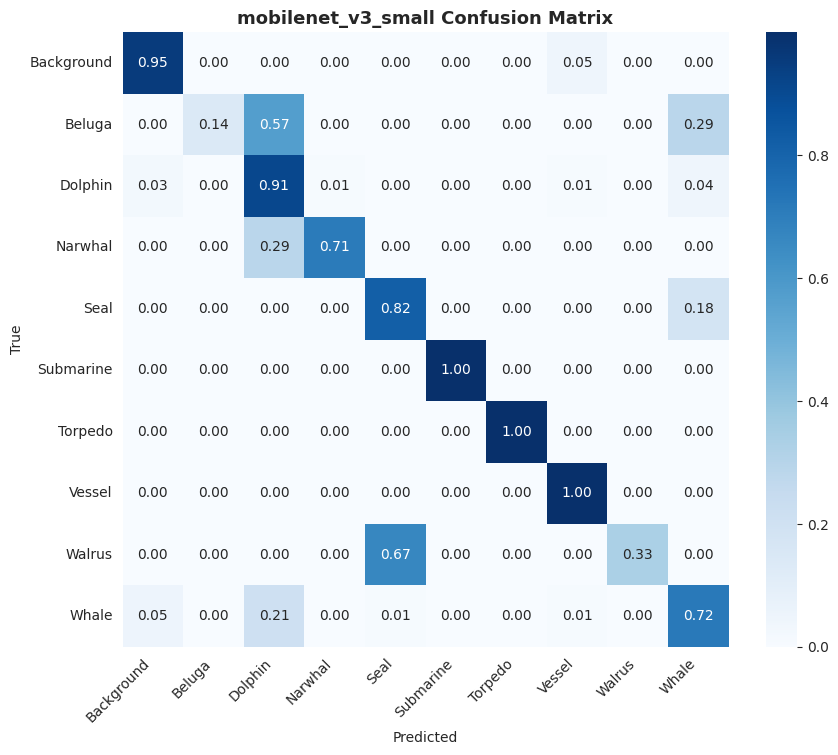


  Training: mobilenet_v3_large
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 140MB/s] 


  Total params    : 4,367,002
  Trainable (head): 165,258
Ep   1/35 | Train 1.4526/0.6151 | Val 1.3702/0.6187 F1=0.2334  ✓ saved
Ep   2/35 | Train 1.2220/0.6956 | Val 1.0975/0.7285 F1=0.3892  ✓ saved
Ep   3/35 | Train 1.1911/0.7055 | Val 1.0231/0.7804 F1=0.4697  ✓ saved
Ep   4/35 | Train 1.1822/0.7105 | Val 1.0059/0.7745 F1=0.5029  ✓ saved
Ep   5/35 | Train 1.1538/0.7220 | Val 0.9713/0.8042 F1=0.5527  ✓ saved
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.0907/0.7474 | Val 0.9142/0.8175 F1=0.5944  ✓ saved
Ep   7/35 | Train 1.0046/0.7888 | Val 0.8603/0.8442 F1=0.6404  ✓ saved
Ep   8/35 | Train 0.9416/0.8250 | Val 0.8306/0.8665 F1=0.6669  ✓ saved
Ep   9/35 | Train 0.9328/0.8315 | Val 0.8065/0.8769 F1=0.6824  ✓ saved
Ep  10/35 | Train 0.8968/0.8467 | Val 0.7936/0.8783 F1=0.6932  ✓ saved
Ep  11/35 | Train 0.8655/0.8588 | Val 0.7843/0.8783 F1=0.6829
Ep  12/35 | Train 0.8596/0.8596 | Val 0.7661/0.8976 F1=0.7179  ✓ saved
Ep  13/35 | Train 0.8238/0.8826 | Val 0.7493/0.9036 F1=0.72

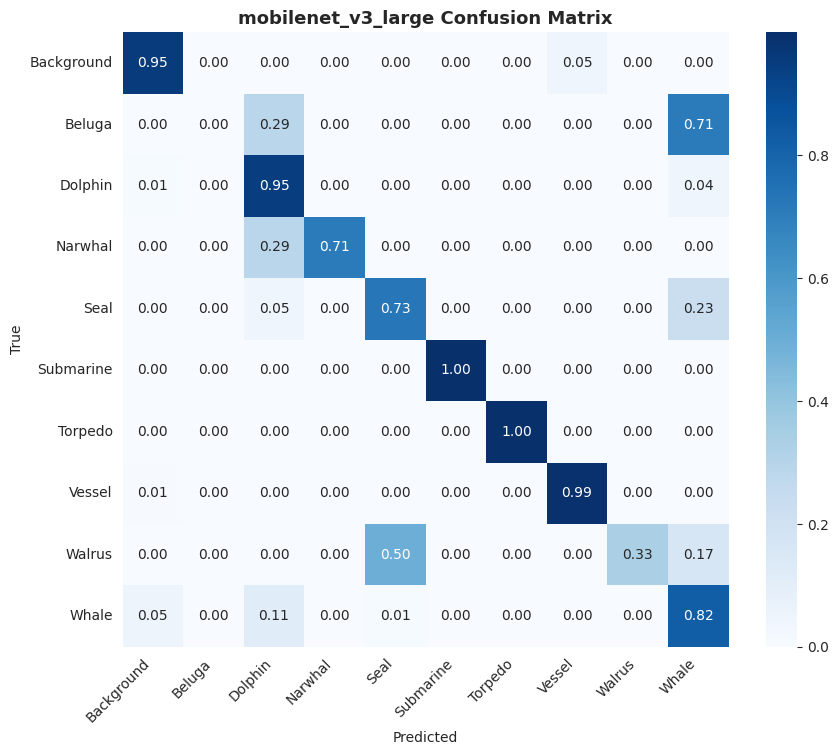


  Training: efficientnet_b0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s] 


  Total params    : 4,172,230
  Trainable (head): 165,258
Ep   1/35 | Train 1.3507/0.6563 | Val 1.0875/0.7893 F1=0.4703  ✓ saved
Ep   2/35 | Train 1.1322/0.7401 | Val 1.0010/0.8116 F1=0.5380  ✓ saved
Ep   3/35 | Train 1.0886/0.7598 | Val 0.9729/0.8160 F1=0.5500  ✓ saved
Ep   4/35 | Train 1.0638/0.7723 | Val 0.9234/0.8412 F1=0.6226  ✓ saved
Ep   5/35 | Train 1.0427/0.7726 | Val 0.9170/0.8398 F1=0.6317  ✓ saved
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 0.9888/0.7993 | Val 0.8709/0.8635 F1=0.6694  ✓ saved
Ep   7/35 | Train 0.9272/0.8349 | Val 0.8096/0.8858 F1=0.6885  ✓ saved
Ep   8/35 | Train 0.8957/0.8418 | Val 0.7797/0.8961 F1=0.7356  ✓ saved
Ep   9/35 | Train 0.8646/0.8653 | Val 0.7531/0.9065 F1=0.7571  ✓ saved
Ep  10/35 | Train 0.8317/0.8740 | Val 0.7422/0.9110 F1=0.7680  ✓ saved
Ep  11/35 | Train 0.8119/0.8871 | Val 0.7258/0.9139 F1=0.7754  ✓ saved
Ep  12/35 | Train 0.7901/0.8944 | Val 0.7091/0.9184 F1=0.8001  ✓ saved
Ep  13/35 | Train 0.7764/0.9044 | Val 0.7001/0.924

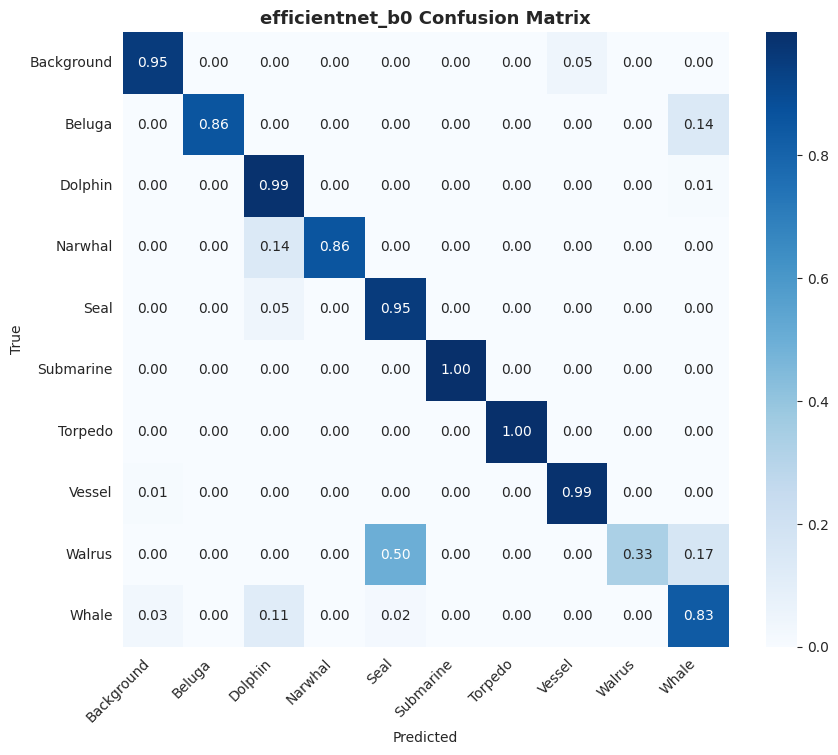


  Training: efficientnet_b1
Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 166MB/s]


  Total params    : 6,677,866
  Trainable (head): 165,258
Ep   1/35 | Train 1.4695/0.6054 | Val 1.0861/0.7493 F1=0.3977  ✓ saved
Ep   2/35 | Train 1.2009/0.7040 | Val 1.0242/0.7522 F1=0.4362  ✓ saved
Ep   3/35 | Train 1.1584/0.7239 | Val 1.0004/0.7537 F1=0.4232
Ep   4/35 | Train 1.1111/0.7367 | Val 0.9773/0.7864 F1=0.5208  ✓ saved
Ep   5/35 | Train 1.1236/0.7294 | Val 0.9949/0.7864 F1=0.5671  ✓ saved
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.0730/0.7519 | Val 0.9189/0.8056 F1=0.5816  ✓ saved
Ep   7/35 | Train 0.9960/0.7841 | Val 0.9061/0.8220 F1=0.5998  ✓ saved
Ep   8/35 | Train 0.9683/0.8056 | Val 0.8724/0.8398 F1=0.6304  ✓ saved
Ep   9/35 | Train 0.9370/0.8145 | Val 1.0067/0.8427 F1=0.6301
Ep  10/35 | Train 0.9269/0.8239 | Val 0.9222/0.8338 F1=0.6252
Ep  11/35 | Train 0.8826/0.8431 | Val 0.8359/0.8591 F1=0.6737  ✓ saved
Ep  12/35 | Train 0.8820/0.8425 | Val 0.8434/0.8620 F1=0.6490
Ep  13/35 | Train 0.8713/0.8504 | Val 0.7931/0.8769 F1=0.6600
Ep  14/35 | Train 0.8557

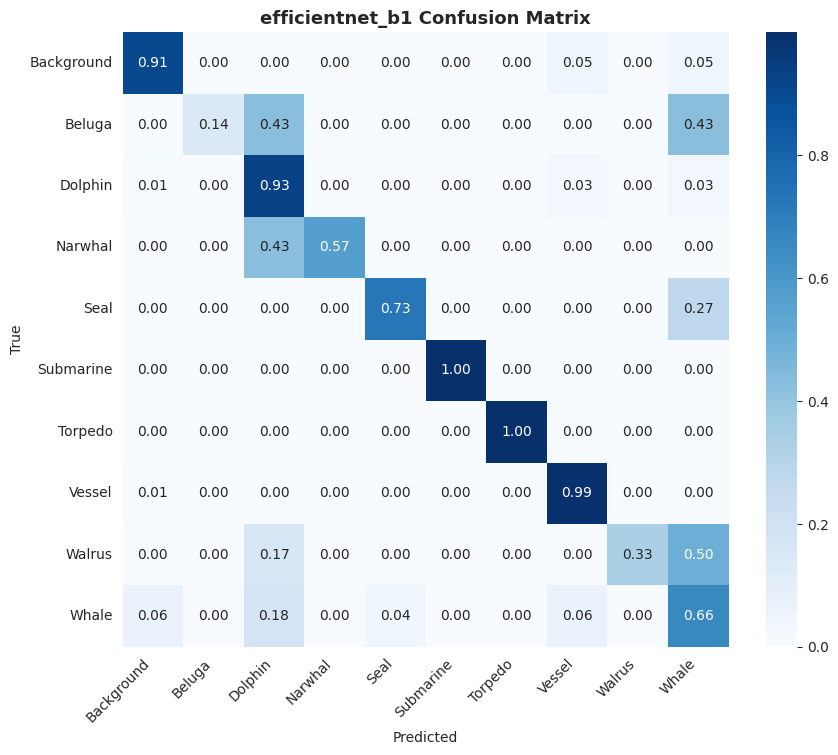


  Training: resnet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


  Total params    : 11,237,194
  Trainable (head): 66,954
Ep   1/35 | Train 1.3845/0.6361 | Val 1.0119/0.7745 F1=0.5185  ✓ saved
Ep   2/35 | Train 1.1676/0.7139 | Val 0.9702/0.8056 F1=0.5735  ✓ saved
Ep   3/35 | Train 1.1298/0.7385 | Val 0.9241/0.8279 F1=0.6271  ✓ saved
Ep   4/35 | Train 1.1050/0.7315 | Val 0.9056/0.8205 F1=0.6233
Ep   5/35 | Train 1.1007/0.7435 | Val 0.8889/0.8457 F1=0.6820  ✓ saved
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 0.9413/0.8205 | Val 0.7672/0.8843 F1=0.7387  ✓ saved
Ep   7/35 | Train 0.8218/0.8756 | Val 0.7106/0.9303 F1=0.8075  ✓ saved
Ep   8/35 | Train 0.7610/0.9088 | Val 0.6951/0.9347 F1=0.8243  ✓ saved
Ep   9/35 | Train 0.7158/0.9285 | Val 0.6723/0.9332 F1=0.8285  ✓ saved
Ep  10/35 | Train 0.6927/0.9403 | Val 0.6379/0.9481 F1=0.8974  ✓ saved
Ep  11/35 | Train 0.6748/0.9468 | Val 0.6300/0.9496 F1=0.8985  ✓ saved
Ep  12/35 | Train 0.6521/0.9557 | Val 0.6097/0.9614 F1=0.9588  ✓ saved
Ep  13/35 | Train 0.6368/0.9633 | Val 0.6161/0.9555 F1=0.90

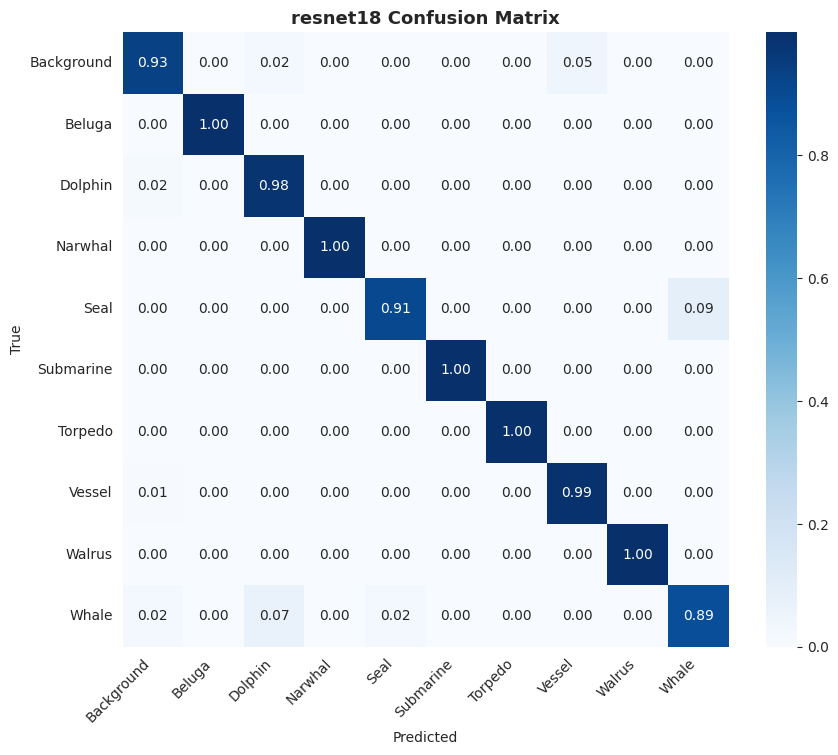


  Training: resnet34
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 209MB/s]


  Total params    : 21,345,354
  Trainable (head): 66,954
Ep   1/35 | Train 1.4244/0.6146 | Val 1.0806/0.7537 F1=0.4798  ✓ saved
Ep   2/35 | Train 1.1879/0.7016 | Val 1.0003/0.7819 F1=0.5354  ✓ saved
Ep   3/35 | Train 1.1611/0.7092 | Val 0.9830/0.7834 F1=0.5508  ✓ saved
Ep   4/35 | Train 1.1345/0.7296 | Val 0.9527/0.8042 F1=0.6067  ✓ saved
Ep   5/35 | Train 1.1052/0.7275 | Val 0.9448/0.8220 F1=0.6096  ✓ saved
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 0.9583/0.8085 | Val 0.7683/0.8872 F1=0.7186  ✓ saved
Ep   7/35 | Train 0.8217/0.8795 | Val 0.7243/0.9006 F1=0.7671  ✓ saved
Ep   8/35 | Train 0.7688/0.8994 | Val 0.6920/0.9199 F1=0.7785  ✓ saved
Ep   9/35 | Train 0.7120/0.9300 | Val 0.6560/0.9318 F1=0.8381  ✓ saved
Ep  10/35 | Train 0.6870/0.9429 | Val 0.6871/0.9332 F1=0.8429  ✓ saved
Ep  11/35 | Train 0.6526/0.9542 | Val 0.6331/0.9392 F1=0.8508  ✓ saved
Ep  12/35 | Train 0.6368/0.9602 | Val 0.6082/0.9525 F1=0.8788  ✓ saved
Ep  13/35 | Train 0.6318/0.9652 | Val 0.6233/0.951

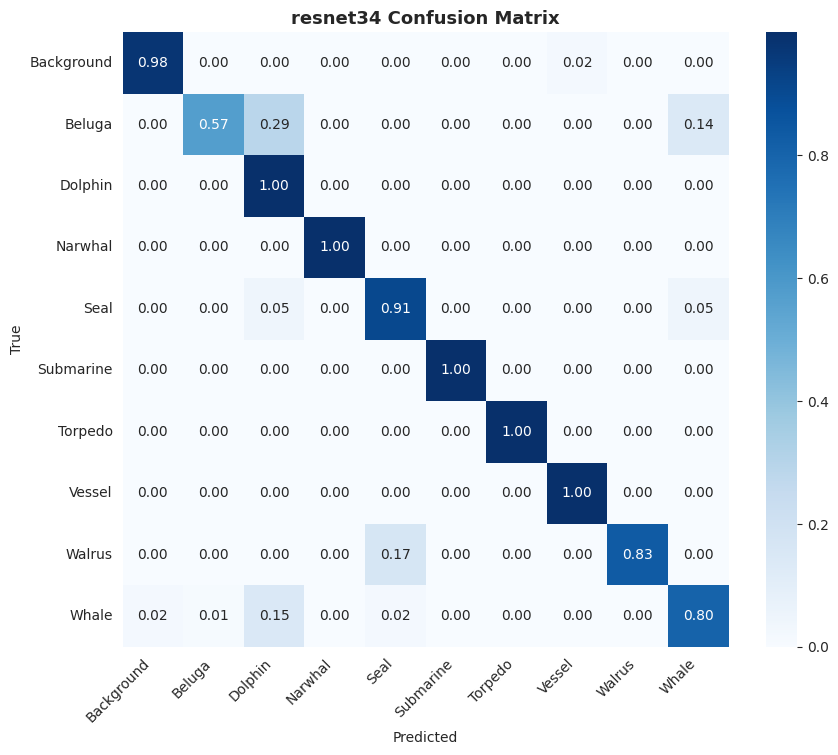


  Training: squeezenet1_1
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 67.5MB/s]

  Total params    : 1,050,890
  Trainable (head): 66,954


Ep   1/35 | Train 2.1717/0.5415 | Val 1.2285/0.6766 F1=0.2649  ✓ saved
Ep   2/35 | Train 1.4067/0.6306 | Val 1.2069/0.6780 F1=0.2797  ✓ saved
Ep   3/35 | Train 1.3551/0.6374 | Val 1.1816/0.6855 F1=0.3013  ✓ saved
Ep   4/35 | Train 1.3278/0.6447 | Val 1.2000/0.6958 F1=0.3211  ✓ saved
Ep   5/35 | Train 1.3021/0.6502 | Val 1.1431/0.6899 F1=0.2846
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.2023/0.6872 | Val 1.0620/0.7226 F1=0.3085
Ep   7/35 | Train 1.1165/0.7202 | Val 1.0200/0.7685 F1=0.3853  ✓ saved
Ep   8/35 | Train 1.0746/0.7433 | Val 0.9446/0.7878 F1=0.4241  ✓ saved
Ep   9/35 | Train 1.0192/0.7760 | Val 0.8812/0.8249 F1=0.4880  ✓ saved
Ep  10/35 | Train 0.9846/0.7998 | Val 0.8568/0.8501 F1=0.5275  ✓ saved
Ep  11/35 | Train 0.9563/0.8103 | Val 0.8224/0.8487 F1=0.5480  ✓ saved
Ep  12/35 | Train 0.9526/0.8137 | Val 0.8143/0.8665 F1=0.5989  ✓ saved
Ep  13/35 | Train 0.9207/0.8355 | Val 0.8003/0.8739 F1=0.5643
Ep  14/35 | Train 0.8976/0.8515 | Val 0.7692/0.8843 F1=0.6510  ✓

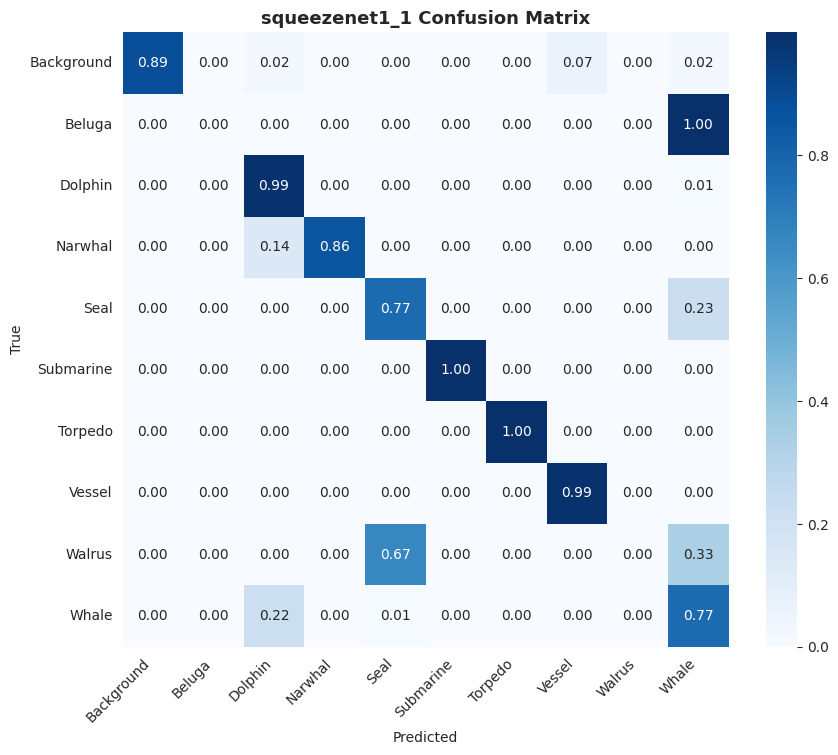

In [11]:
BACKBONES = [
    'mobilenet_v3_small',
    'mobilenet_v3_large',
    'efficientnet_b0',
    'efficientnet_b1',
    'resnet18',
    'resnet34',
    'squeezenet1_1',
]

WARMUP_EPOCHS  = 5
TOTAL_EPOCHS   = 35
PATIENCE       = 8

all_results = {}   # will hold {name: (labels, preds, history, param_count)}

for backbone_name in BACKBONES:
    print(f'\n{"="*60}')
    print(f'  Training: {backbone_name}')
    print(f'{"="*60}')

    model = PretrainedAcoustic(num_classes=NUM_CLASSES,
                               backbone_name=backbone_name).to(DEVICE)
    model.freeze_backbone()

    n_params = count_params(model)
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Total params    : {n_params:,}')
    print(f'  Trainable (head): {n_trainable:,}')

    history, val_labels, val_preds = train(
        model, train_loader, val_loader,
        num_epochs=TOTAL_EPOCHS,
        lr=1e-3,
        patience=PATIENCE,
        save_path=f'best_{backbone_name}.pth',
        warmup_epochs=WARMUP_EPOCHS,
        warmup_lr=1e-3,
        finetune_lr=5e-5,
        device=DEVICE
    )

    # Reload best checkpoint and get final predictions
    model.load_state_dict(torch.load(f'best_{backbone_name}.pth'))
    final_labels, final_preds = evaluate(model, val_loader)

    all_results[backbone_name] = {
        'labels':   final_labels,
        'preds':    final_preds,
        'history':  history,
        'n_params': n_params,
    }

    # Per-model confusion matrix
    plot_confusion(final_labels, final_preds, CLASS_NAMES,
                   title=f'{backbone_name} Confusion Matrix')

    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

## 10 · Evaluation & Visualizations


─── AcousticCNN ───────────────────────────────
  Accuracy : 0.9866
  Precision: 0.9694
  Recall   : 0.9715
  F1 macro : 0.9689
              precision    recall  f1-score   support

  Background       0.98      1.00      0.99        44
      Beluga       0.88      1.00      0.93         7
     Dolphin       0.97      1.00      0.98       116
     Narwhal       1.00      1.00      1.00         7
        Seal       0.88      0.95      0.91        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       1.00      1.00      1.00       300
      Walrus       1.00      0.83      0.91         6
       Whale       1.00      0.93      0.96        96

    accuracy                           0.99       674
   macro avg       0.97      0.97      0.97       674
weighted avg       0.99      0.99      0.99       674



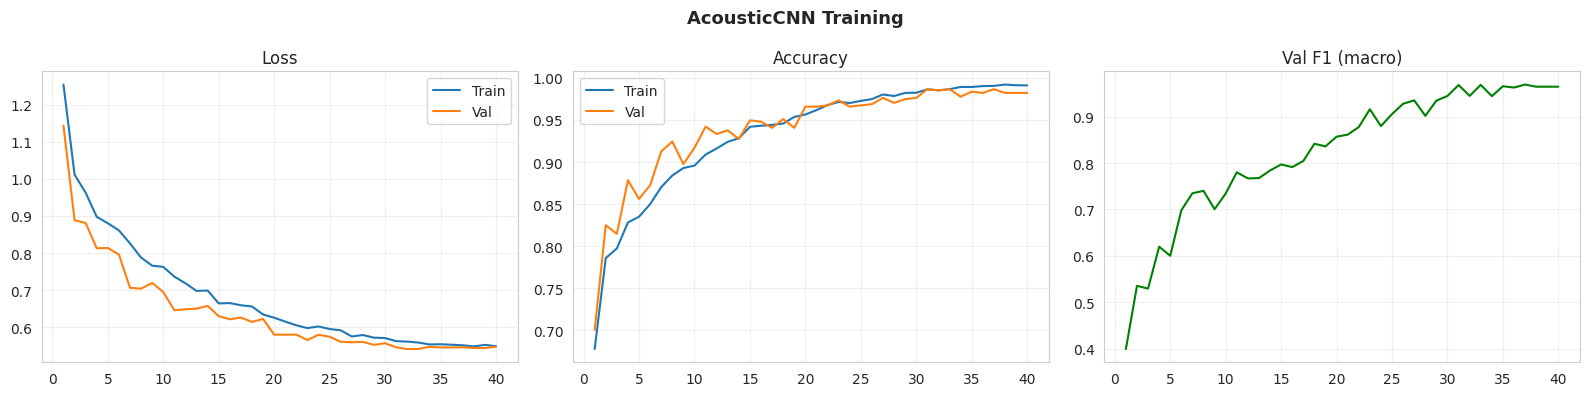

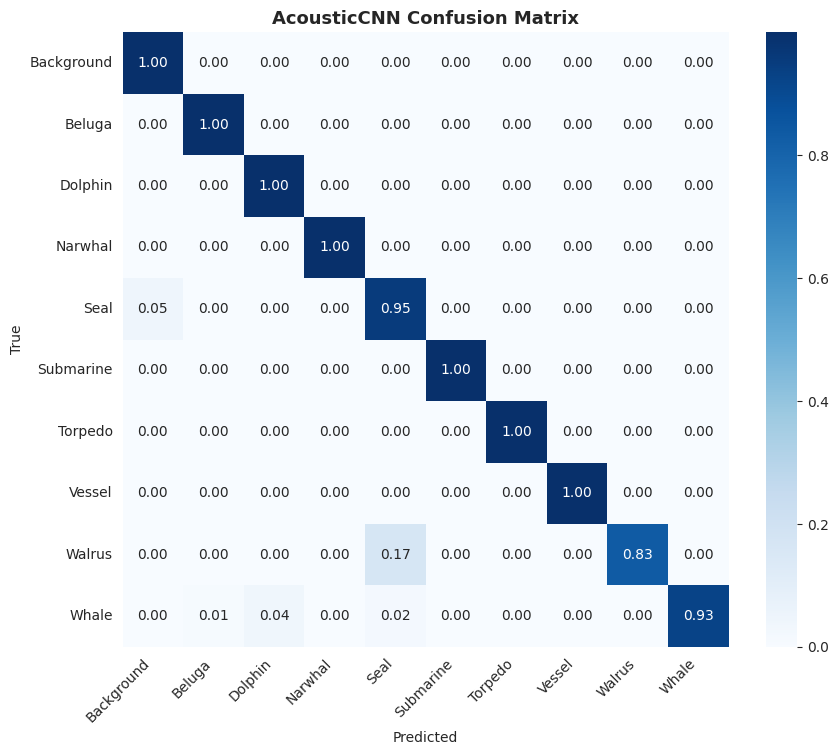


─── mobilenet_v3_small ───────────────────────────────
  Accuracy : 0.9169
  Precision: 0.9092
  Recall   : 0.7592
  F1 macro : 0.7834
              precision    recall  f1-score   support

  Background       0.82      0.95      0.88        44
      Beluga       1.00      0.14      0.25         7
     Dolphin       0.80      0.91      0.85       116
     Narwhal       0.83      0.71      0.77         7
        Seal       0.78      0.82      0.80        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.99      1.00      0.99       300
      Walrus       1.00      0.33      0.50         6
       Whale       0.86      0.72      0.78        96

    accuracy                           0.92       674
   macro avg       0.91      0.76      0.78       674
weighted avg       0.92      0.92      0.91       674



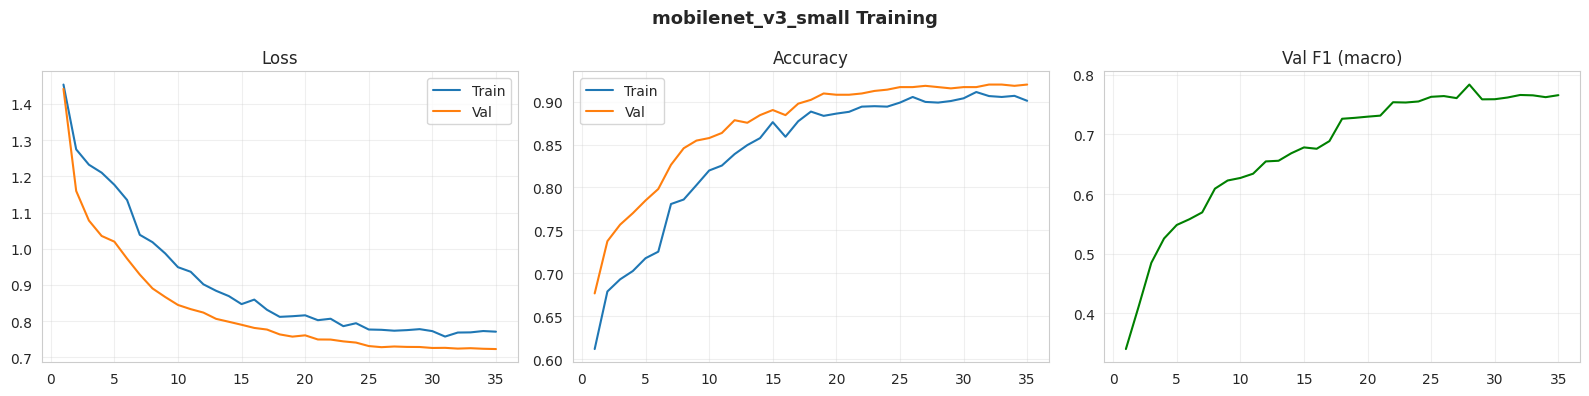

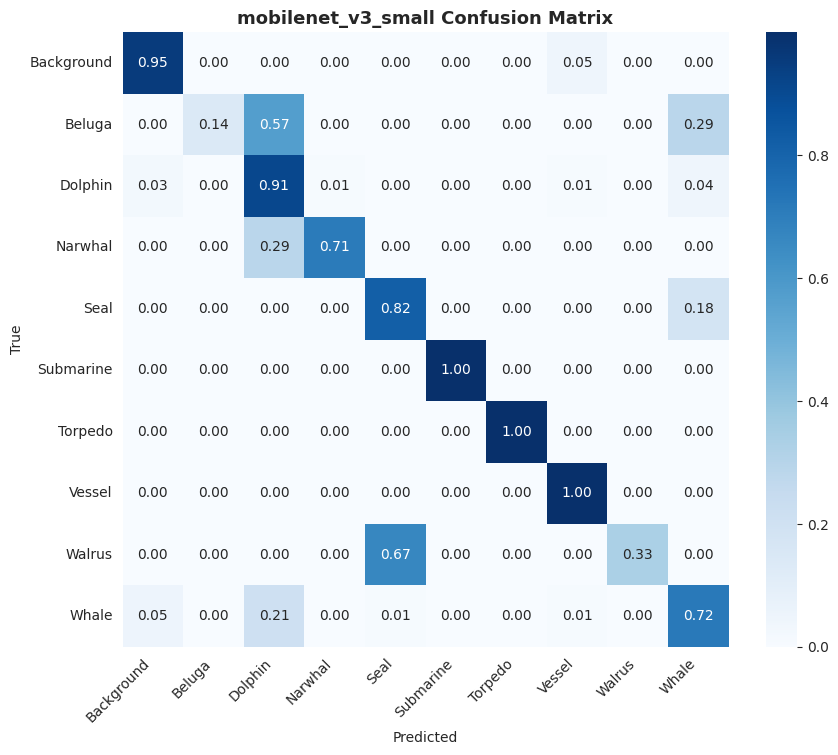


─── mobilenet_v3_large ───────────────────────────────
  Accuracy : 0.9318
  Precision: 0.8338
  Recall   : 0.7494
  F1 macro : 0.7719
              precision    recall  f1-score   support

  Background       0.84      0.95      0.89        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.87      0.95      0.91       116
     Narwhal       1.00      0.71      0.83         7
        Seal       0.80      0.73      0.76        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.99      0.99      0.99       300
      Walrus       1.00      0.33      0.50         6
       Whale       0.83      0.82      0.83        96

    accuracy                           0.93       674
   macro avg       0.83      0.75      0.77       674
weighted avg       0.92      0.93      0.93       674



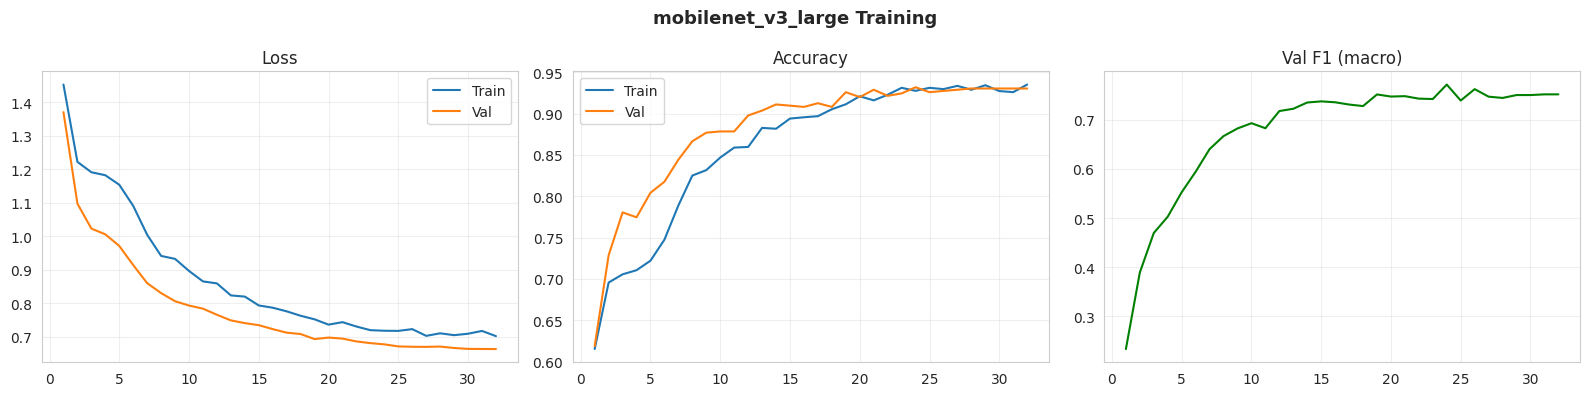

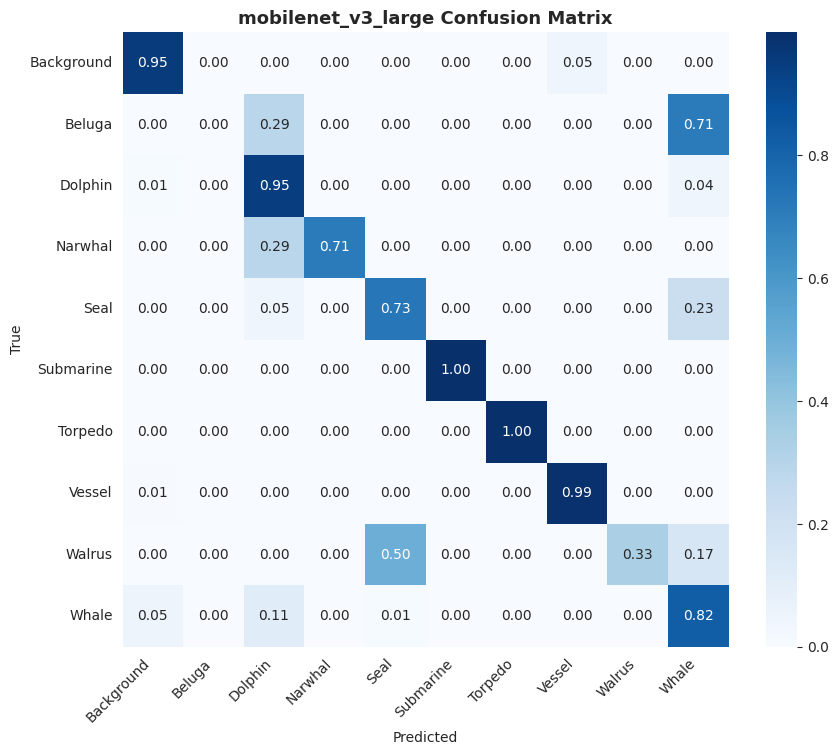


─── efficientnet_b0 ───────────────────────────────
  Accuracy : 0.9570
  Precision: 0.9538
  Recall   : 0.8771
  F1 macro : 0.8962
              precision    recall  f1-score   support

  Background       0.88      0.95      0.91        44
      Beluga       1.00      0.86      0.92         7
     Dolphin       0.90      0.99      0.94       116
     Narwhal       1.00      0.86      0.92         7
        Seal       0.81      0.95      0.88        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.99      0.99      0.99       300
      Walrus       1.00      0.33      0.50         6
       Whale       0.96      0.83      0.89        96

    accuracy                           0.96       674
   macro avg       0.95      0.88      0.90       674
weighted avg       0.96      0.96      0.96       674



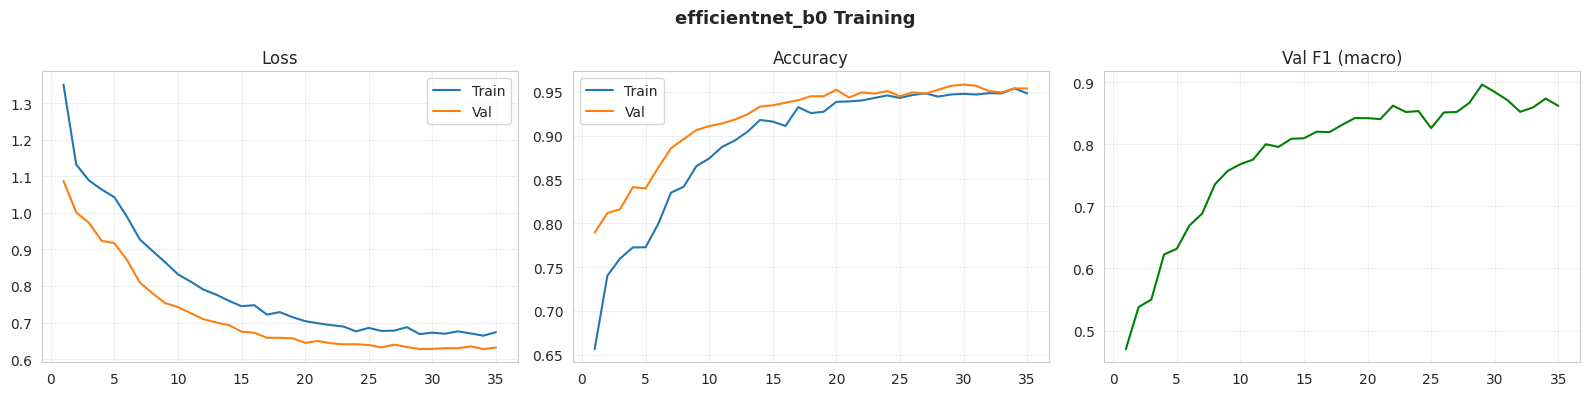

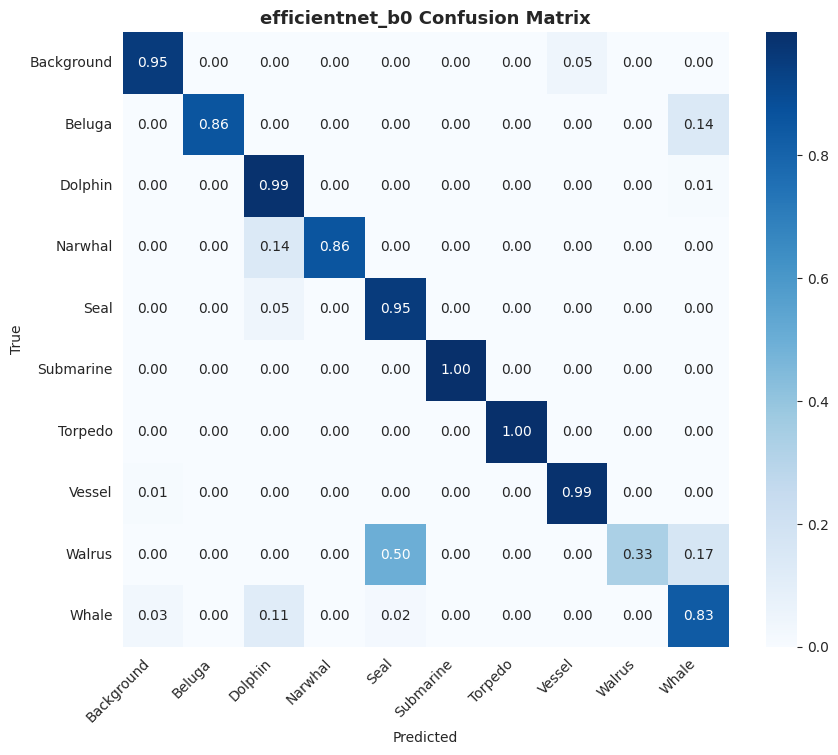


─── efficientnet_b1 ───────────────────────────────
  Accuracy : 0.9021
  Precision: 0.9177
  Recall   : 0.7265
  F1 macro : 0.7661
              precision    recall  f1-score   support

  Background       0.82      0.91      0.86        44
      Beluga       1.00      0.14      0.25         7
     Dolphin       0.82      0.93      0.87       116
     Narwhal       1.00      0.57      0.73         7
        Seal       0.80      0.73      0.76        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.96      0.99      0.98       300
      Walrus       1.00      0.33      0.50         6
       Whale       0.78      0.66      0.71        96

    accuracy                           0.90       674
   macro avg       0.92      0.73      0.77       674
weighted avg       0.90      0.90      0.90       674



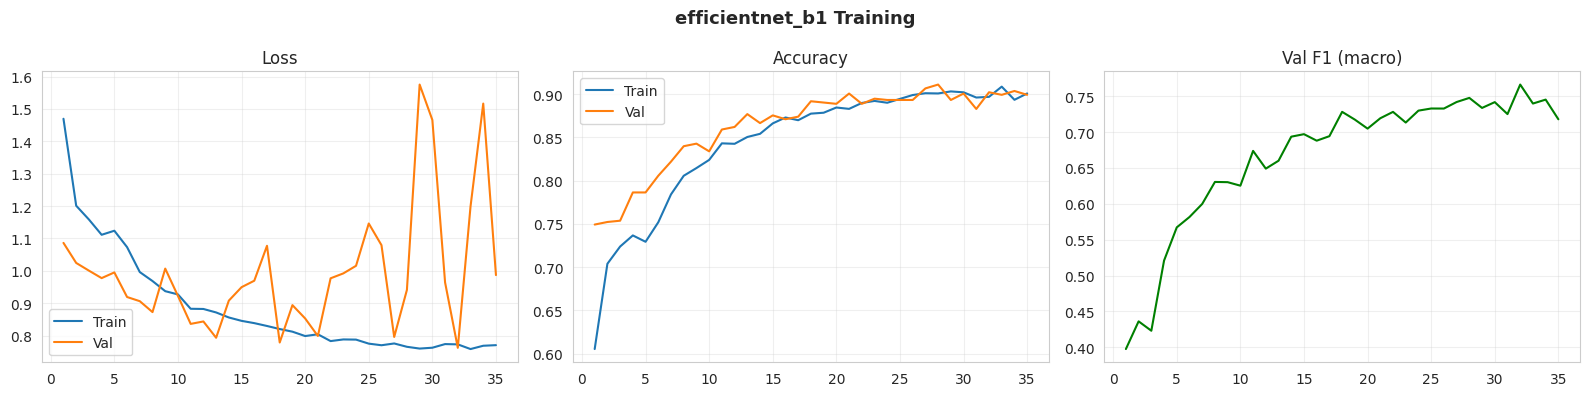

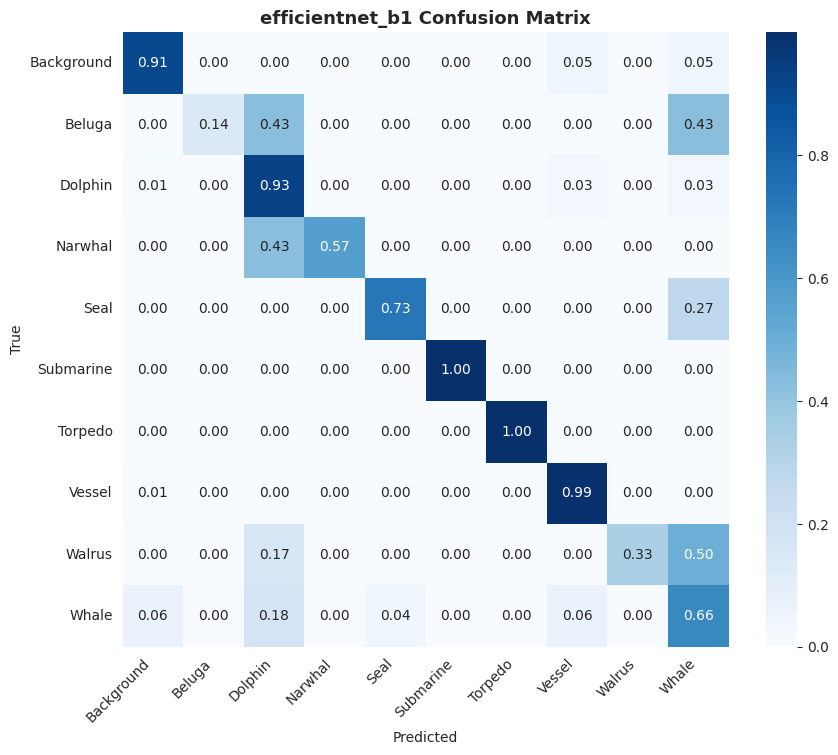


─── resnet18 ───────────────────────────────
  Accuracy : 0.9688
  Precision: 0.9675
  Recall   : 0.9699
  F1 macro : 0.9684
              precision    recall  f1-score   support

  Background       0.87      0.93      0.90        44
      Beluga       1.00      1.00      1.00         7
     Dolphin       0.93      0.98      0.96       116
     Narwhal       1.00      1.00      1.00         7
        Seal       0.91      0.91      0.91        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.99      0.99      0.99       300
      Walrus       1.00      1.00      1.00         6
       Whale       0.97      0.89      0.92        96

    accuracy                           0.97       674
   macro avg       0.97      0.97      0.97       674
weighted avg       0.97      0.97      0.97       674



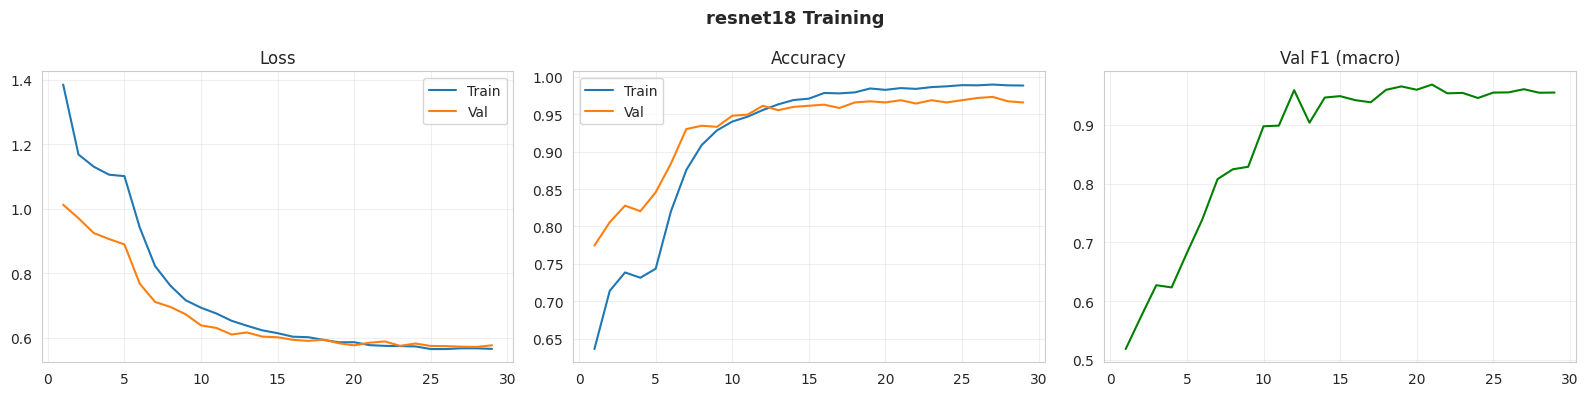

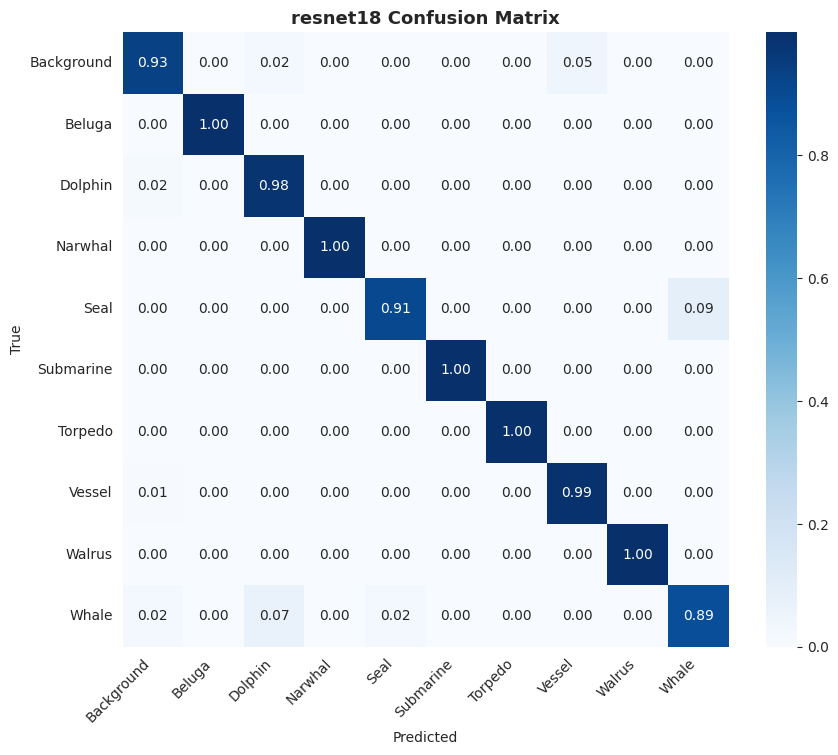


─── resnet34 ───────────────────────────────
  Accuracy : 0.9599
  Precision: 0.9448
  Recall   : 0.9090
  F1 macro : 0.9229
              precision    recall  f1-score   support

  Background       0.93      0.98      0.96        44
      Beluga       0.80      0.57      0.67         7
     Dolphin       0.87      1.00      0.93       116
     Narwhal       1.00      1.00      1.00         7
        Seal       0.87      0.91      0.89        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       1.00      1.00      1.00       300
      Walrus       1.00      0.83      0.91         6
       Whale       0.97      0.80      0.88        96

    accuracy                           0.96       674
   macro avg       0.94      0.91      0.92       674
weighted avg       0.96      0.96      0.96       674



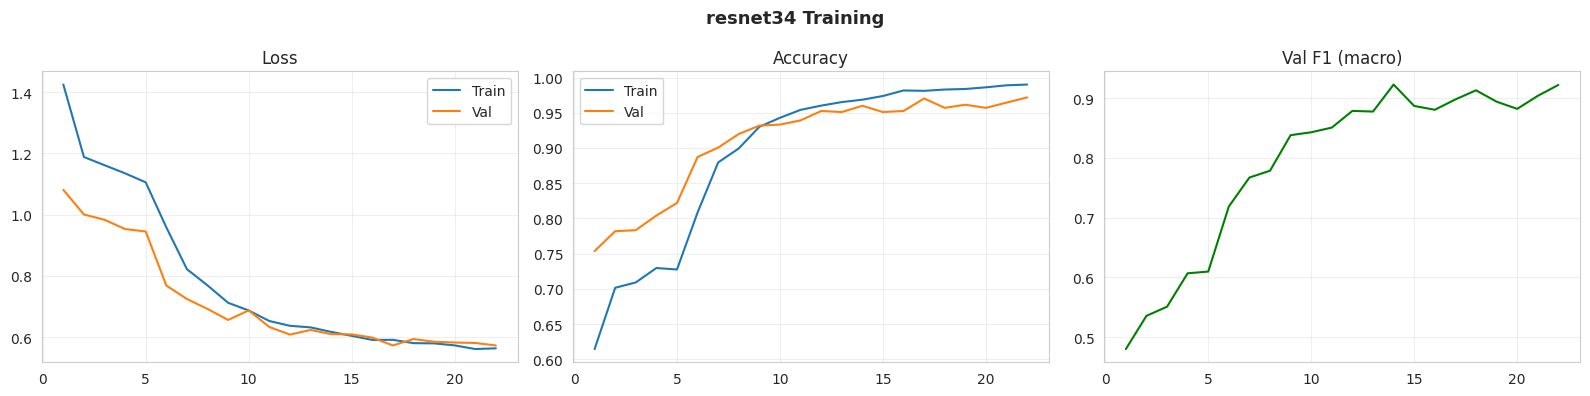

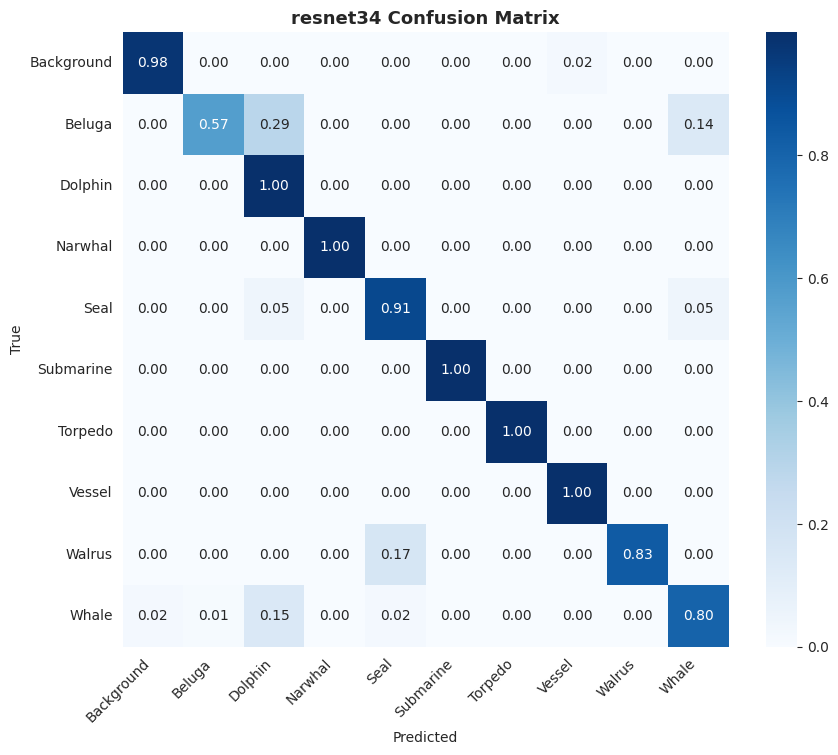


─── squeezenet1_1 ───────────────────────────────
  Accuracy : 0.9258
  Precision: 0.7359
  Recall   : 0.7268
  F1 macro : 0.7298
              precision    recall  f1-score   support

  Background       0.97      0.89      0.93        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.83      0.99      0.91       116
     Narwhal       1.00      0.86      0.92         7
        Seal       0.77      0.77      0.77        22
   Submarine       0.97      1.00      0.99        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.99      0.99      0.99       300
      Walrus       0.00      0.00      0.00         6
       Whale       0.81      0.77      0.79        96

    accuracy                           0.93       674
   macro avg       0.74      0.73      0.73       674
weighted avg       0.91      0.93      0.92       674



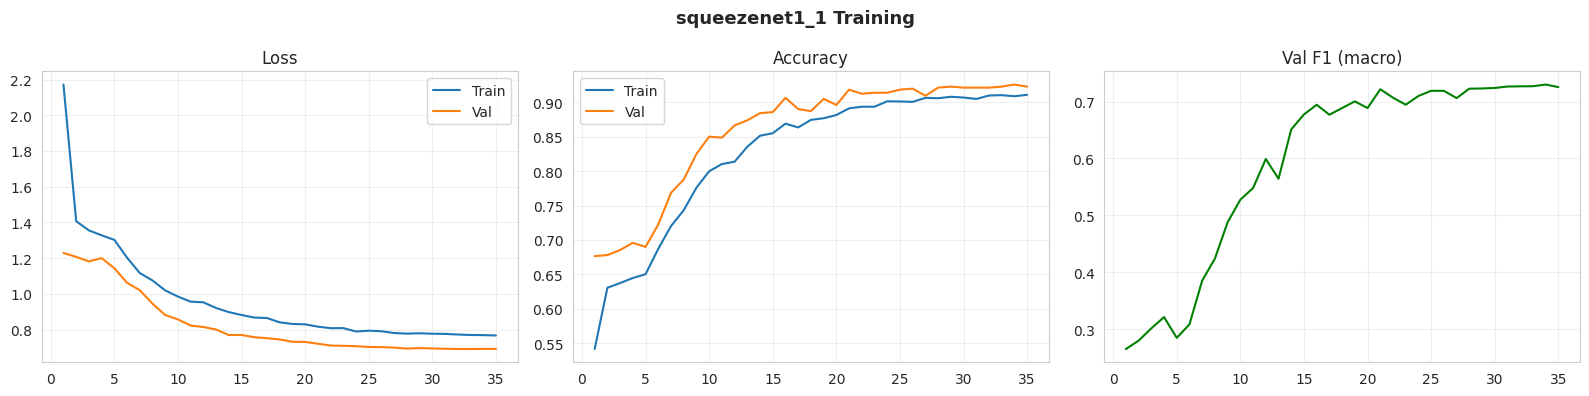

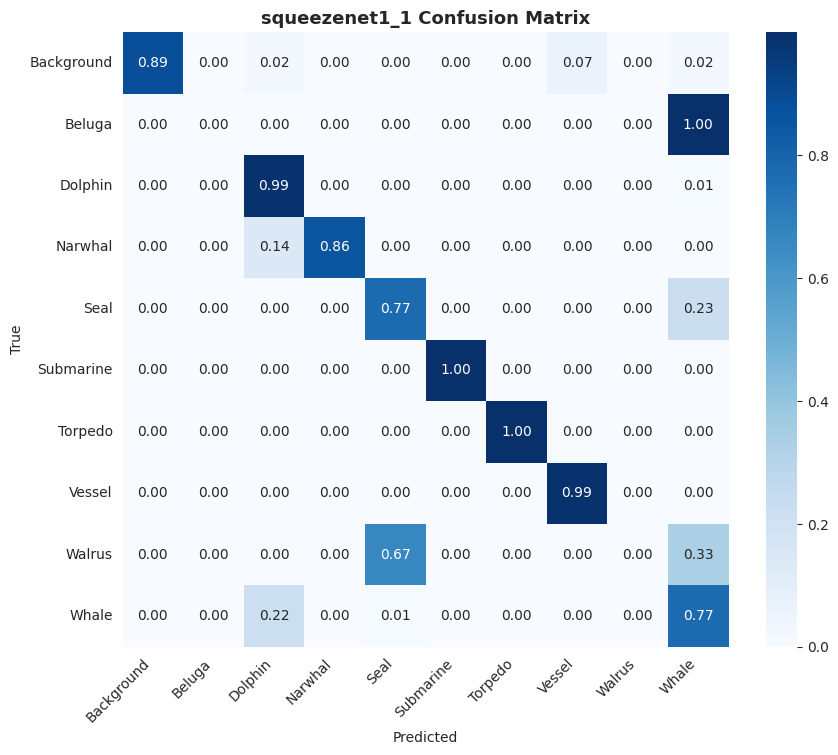

In [12]:
# ── AcousticCNN results ───────────────────────────────────────
lbl_cnn, pr_cnn = evaluate(model_cnn, val_loader)
print_metrics(lbl_cnn, pr_cnn, 'AcousticCNN')
plot_history(history_cnn, 'AcousticCNN Training')
plot_confusion(lbl_cnn, pr_cnn, CLASS_NAMES, 'AcousticCNN Confusion Matrix')

# ── All pretrained backbones ──────────────────────────────────
for backbone_name, res in all_results.items():
    print_metrics(res['labels'], res['preds'], backbone_name)
    plot_history(res['history'], f'{backbone_name} Training')
    plot_confusion(res['labels'], res['preds'], CLASS_NAMES,
                   f'{backbone_name} Confusion Matrix')

## 11 · Model Comparison

                        Params  Accuracy  Precision  Recall      F1
Model                                                              
AcousticCNN (proposed)   2.10M    0.9866     0.9694  0.9715  0.9689
resnet18                11.24M    0.9688     0.9675  0.9699  0.9684
resnet34                21.35M    0.9599     0.9448  0.9090  0.9229
efficientnet_b0          4.17M    0.9570     0.9538  0.8771  0.8962
mobilenet_v3_small       1.65M    0.9169     0.9092  0.7592  0.7834
mobilenet_v3_large       4.37M    0.9318     0.8338  0.7494  0.7719
efficientnet_b1          6.68M    0.9021     0.9177  0.7265  0.7661
squeezenet1_1            1.05M    0.9258     0.7359  0.7268  0.7298


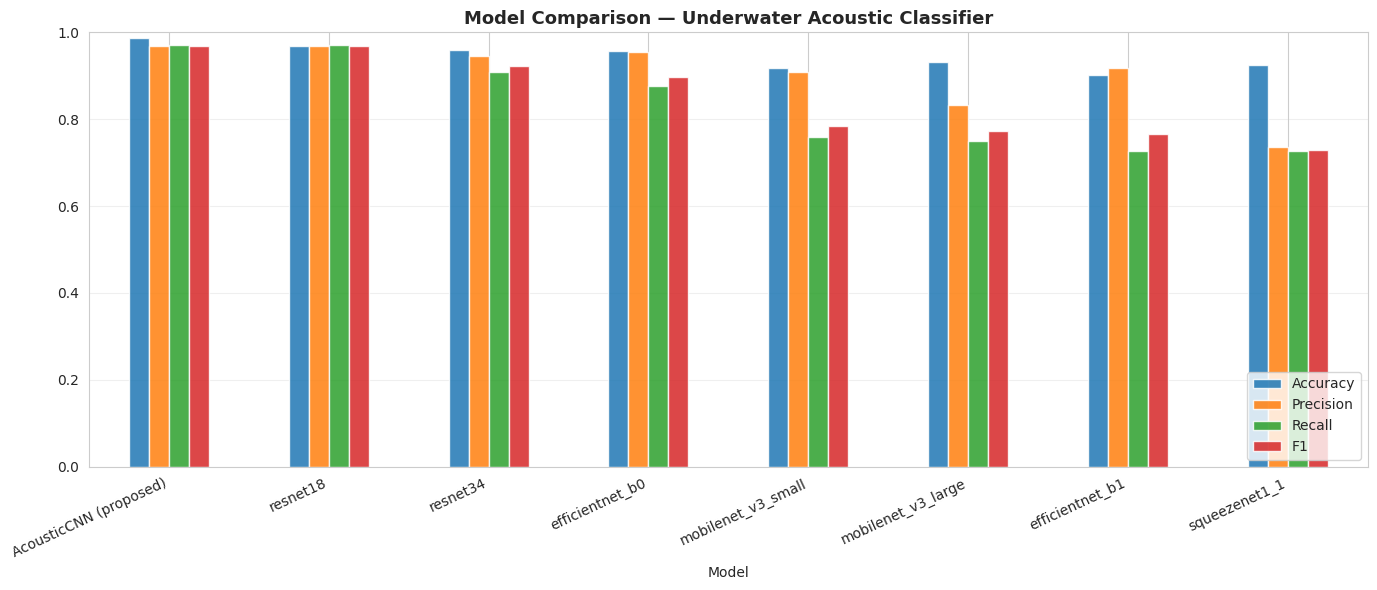

In [13]:
def full_comparison_table(cnn_labels, cnn_preds, cnn_params, pretrained_results: dict):
    rows = []

    # AcousticCNN row
    rows.append({
        'Model':      'AcousticCNN (proposed)',
        'Params':      cnn_params,
        'Accuracy':    accuracy_score(cnn_labels, cnn_preds),
        'Precision':   precision_score(cnn_labels, cnn_preds, average='macro', zero_division=0),
        'Recall':      recall_score(cnn_labels, cnn_preds, average='macro', zero_division=0),
        'F1':          f1_score(cnn_labels, cnn_preds, average='macro', zero_division=0),
    })

    # Pretrained rows
    for name, res in pretrained_results.items():
        rows.append({
            'Model':     name,
            'Params':    res['n_params'],
            'Accuracy':  accuracy_score(res['labels'], res['preds']),
            'Precision': precision_score(res['labels'], res['preds'], average='macro', zero_division=0),
            'Recall':    recall_score(res['labels'], res['preds'], average='macro', zero_division=0),
            'F1':        f1_score(res['labels'], res['preds'], average='macro', zero_division=0),
        })

    df = pd.DataFrame(rows).set_index('Model').sort_values('F1', ascending=False)
    df['Params'] = df['Params'].apply(lambda x: f'{x/1e6:.2f}M')
    print(df.round(4).to_string())

    # Bar chart — metrics only (no Params column)
    plot_df = df[['Accuracy', 'Precision', 'Recall', 'F1']].astype(float)
    ax = plot_df.plot(kind='bar', figsize=(14, 6), ylim=(0, 1), alpha=0.85)
    ax.set_title('Model Comparison — Underwater Acoustic Classifier',
                 fontsize=13, fontweight='bold')
    ax.set_xticklabels(plot_df.index, rotation=25, ha='right')
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('full_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df


comparison_df = full_comparison_table(
    cnn_labels=lbl_cnn,
    cnn_preds=pr_cnn,
    cnn_params=count_params(model_cnn),
    pretrained_results=all_results
)

# Testing other pretrained models


─── Test Results: AcousticCNN ───────────────────
  Accuracy  : 0.9866
  Precision : 0.9694
  Recall    : 0.9715
  F1 macro  : 0.9689
  Avg latency: 0.194 ms/sample
              precision    recall  f1-score   support

  Background       0.98      1.00      0.99        44
      Beluga       0.88      1.00      0.93         7
     Dolphin       0.97      1.00      0.98       116
     Narwhal       1.00      1.00      1.00         7
        Seal       0.88      0.95      0.91        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       1.00      1.00      1.00       300
      Walrus       1.00      0.83      0.91         6
       Whale       1.00      0.93      0.96        96

    accuracy                           0.99       674
   macro avg       0.97      0.97      0.97       674
weighted avg       0.99      0.99      0.99       674



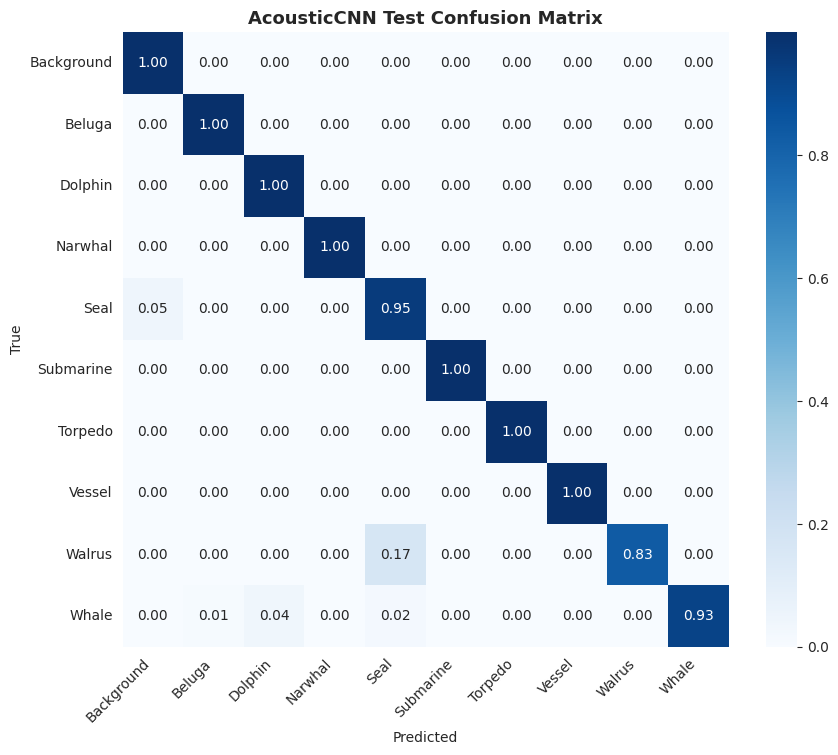


─── Test Results: mobilenet_v3_small ───────────────────
  Accuracy  : 0.9169
  Precision : 0.9092
  Recall    : 0.7592
  F1 macro  : 0.7834
  Avg latency: 0.408 ms/sample
              precision    recall  f1-score   support

  Background       0.82      0.95      0.88        44
      Beluga       1.00      0.14      0.25         7
     Dolphin       0.80      0.91      0.85       116
     Narwhal       0.83      0.71      0.77         7
        Seal       0.78      0.82      0.80        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.99      1.00      0.99       300
      Walrus       1.00      0.33      0.50         6
       Whale       0.86      0.72      0.78        96

    accuracy                           0.92       674
   macro avg       0.91      0.76      0.78       674
weighted avg       0.92      0.92      0.91       674



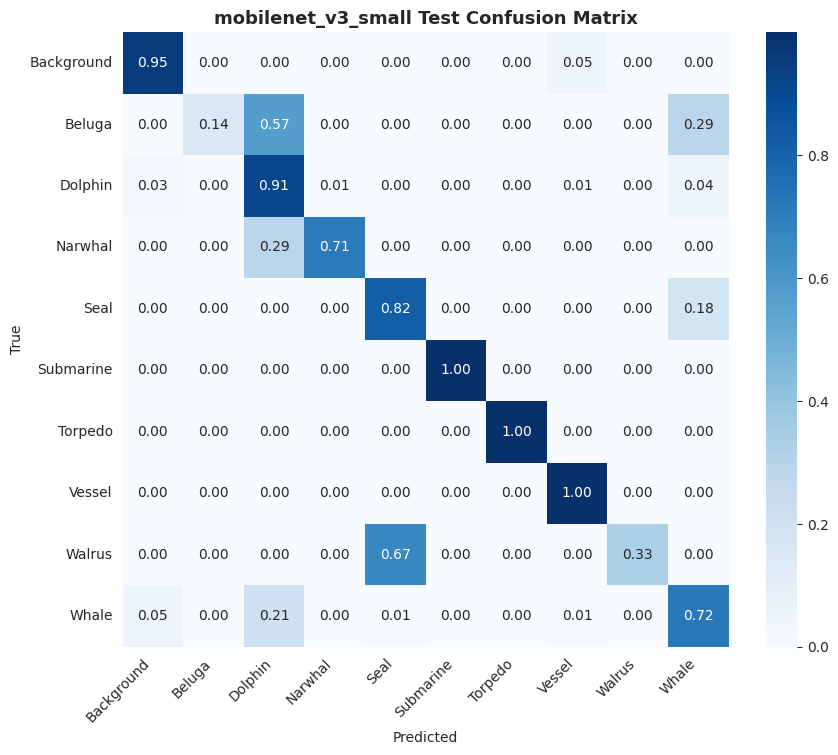


─── Test Results: mobilenet_v3_large ───────────────────
  Accuracy  : 0.9318
  Precision : 0.8338
  Recall    : 0.7494
  F1 macro  : 0.7719
  Avg latency: 0.485 ms/sample
              precision    recall  f1-score   support

  Background       0.84      0.95      0.89        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.87      0.95      0.91       116
     Narwhal       1.00      0.71      0.83         7
        Seal       0.80      0.73      0.76        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.99      0.99      0.99       300
      Walrus       1.00      0.33      0.50         6
       Whale       0.83      0.82      0.83        96

    accuracy                           0.93       674
   macro avg       0.83      0.75      0.77       674
weighted avg       0.92      0.93      0.93       674



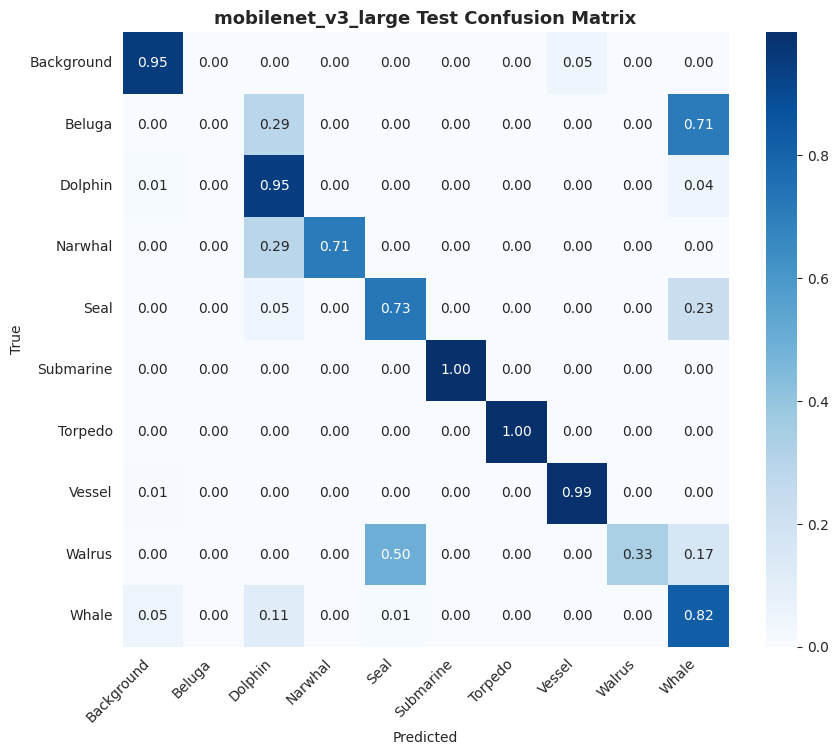


─── Test Results: efficientnet_b0 ───────────────────
  Accuracy  : 0.9570
  Precision : 0.9538
  Recall    : 0.8771
  F1 macro  : 0.8962
  Avg latency: 0.568 ms/sample
              precision    recall  f1-score   support

  Background       0.88      0.95      0.91        44
      Beluga       1.00      0.86      0.92         7
     Dolphin       0.90      0.99      0.94       116
     Narwhal       1.00      0.86      0.92         7
        Seal       0.81      0.95      0.88        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.99      0.99      0.99       300
      Walrus       1.00      0.33      0.50         6
       Whale       0.96      0.83      0.89        96

    accuracy                           0.96       674
   macro avg       0.95      0.88      0.90       674
weighted avg       0.96      0.96      0.96       674



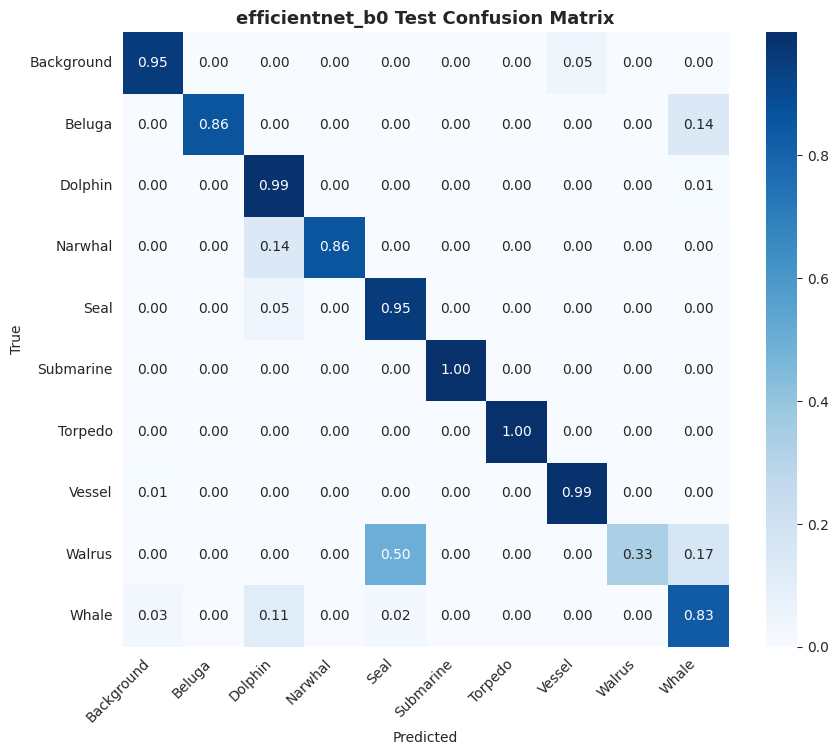


─── Test Results: efficientnet_b1 ───────────────────
  Accuracy  : 0.9021
  Precision : 0.9177
  Recall    : 0.7265
  F1 macro  : 0.7661
  Avg latency: 0.718 ms/sample
              precision    recall  f1-score   support

  Background       0.82      0.91      0.86        44
      Beluga       1.00      0.14      0.25         7
     Dolphin       0.82      0.93      0.87       116
     Narwhal       1.00      0.57      0.73         7
        Seal       0.80      0.73      0.76        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.96      0.99      0.98       300
      Walrus       1.00      0.33      0.50         6
       Whale       0.78      0.66      0.71        96

    accuracy                           0.90       674
   macro avg       0.92      0.73      0.77       674
weighted avg       0.90      0.90      0.90       674



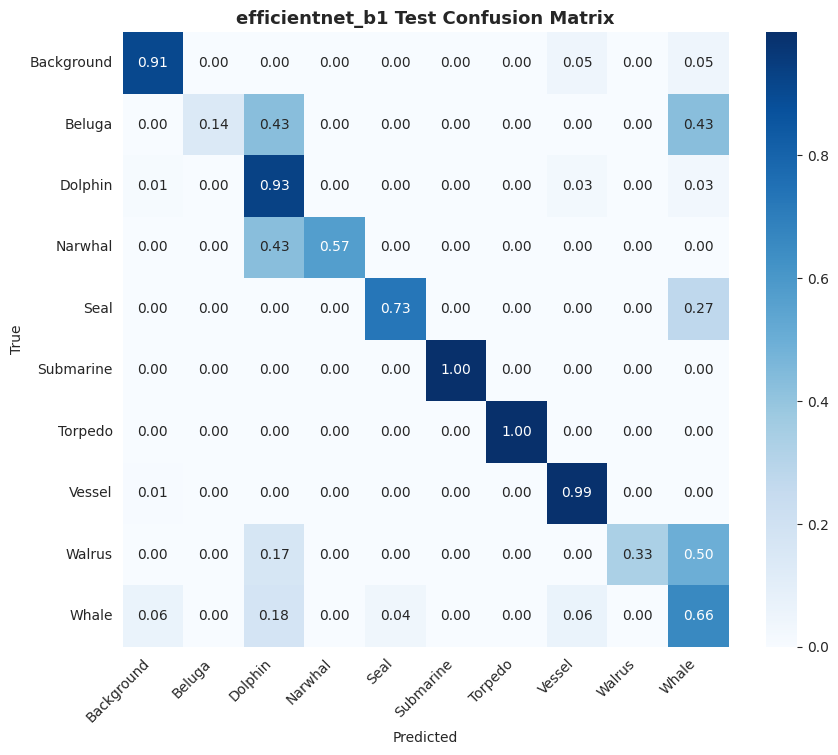


─── Test Results: resnet18 ───────────────────
  Accuracy  : 0.9688
  Precision : 0.9675
  Recall    : 0.9699
  F1 macro  : 0.9684
  Avg latency: 0.222 ms/sample
              precision    recall  f1-score   support

  Background       0.87      0.93      0.90        44
      Beluga       1.00      1.00      1.00         7
     Dolphin       0.93      0.98      0.96       116
     Narwhal       1.00      1.00      1.00         7
        Seal       0.91      0.91      0.91        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.99      0.99      0.99       300
      Walrus       1.00      1.00      1.00         6
       Whale       0.97      0.89      0.92        96

    accuracy                           0.97       674
   macro avg       0.97      0.97      0.97       674
weighted avg       0.97      0.97      0.97       674



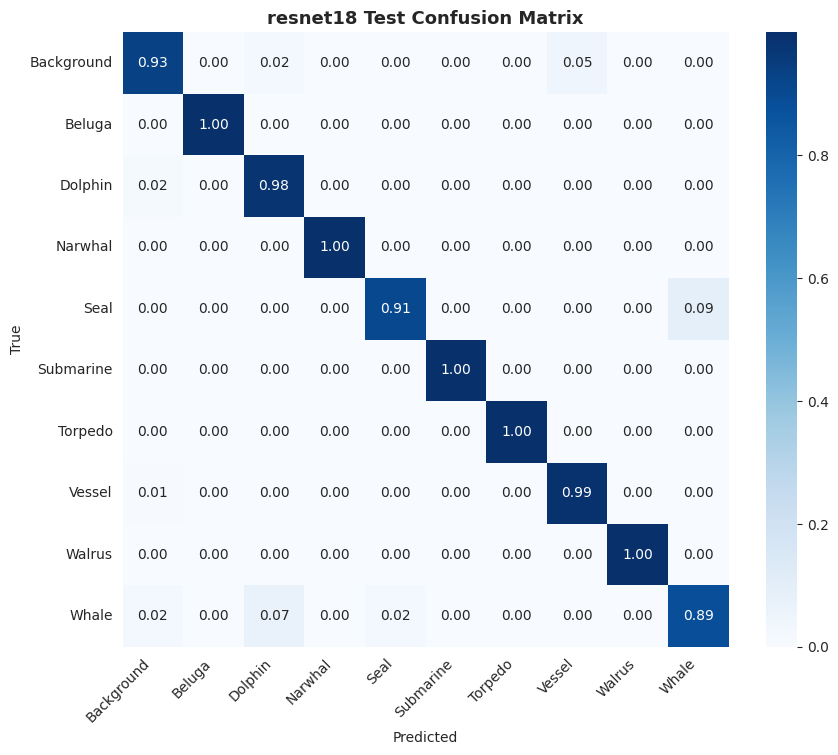


─── Test Results: resnet34 ───────────────────
  Accuracy  : 0.9599
  Precision : 0.9448
  Recall    : 0.9090
  F1 macro  : 0.9229
  Avg latency: 0.300 ms/sample
              precision    recall  f1-score   support

  Background       0.93      0.98      0.96        44
      Beluga       0.80      0.57      0.67         7
     Dolphin       0.87      1.00      0.93       116
     Narwhal       1.00      1.00      1.00         7
        Seal       0.87      0.91      0.89        22
   Submarine       1.00      1.00      1.00        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       1.00      1.00      1.00       300
      Walrus       1.00      0.83      0.91         6
       Whale       0.97      0.80      0.88        96

    accuracy                           0.96       674
   macro avg       0.94      0.91      0.92       674
weighted avg       0.96      0.96      0.96       674



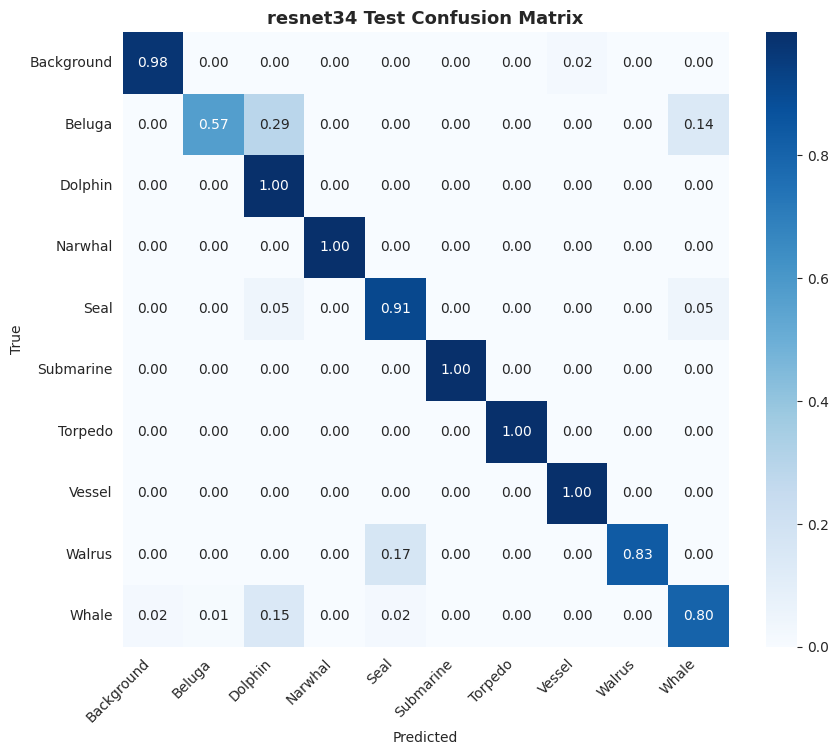


─── Test Results: squeezenet1_1 ───────────────────
  Accuracy  : 0.9258
  Precision : 0.7359
  Recall    : 0.7268
  F1 macro  : 0.7298
  Avg latency: 0.224 ms/sample
              precision    recall  f1-score   support

  Background       0.97      0.89      0.93        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.83      0.99      0.91       116
     Narwhal       1.00      0.86      0.92         7
        Seal       0.77      0.77      0.77        22
   Submarine       0.97      1.00      0.99        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.99      0.99      0.99       300
      Walrus       0.00      0.00      0.00         6
       Whale       0.81      0.77      0.79        96

    accuracy                           0.93       674
   macro avg       0.74      0.73      0.73       674
weighted avg       0.91      0.93      0.92       674



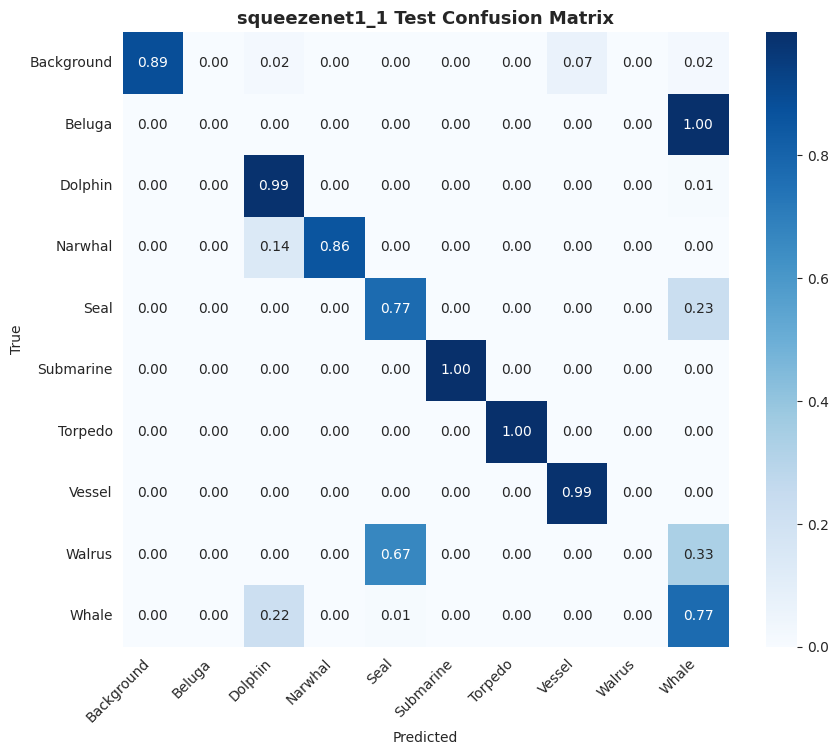


FINAL TEST SUMMARY
                    Accuracy  Precision  Recall      F1  Latency(ms)
Model                                                               
AcousticCNN           0.9866     0.9694  0.9715  0.9689       0.1936
resnet18              0.9688     0.9675  0.9699  0.9684       0.2220
resnet34              0.9599     0.9448  0.9090  0.9229       0.2996
efficientnet_b0       0.9570     0.9538  0.8771  0.8962       0.5679
mobilenet_v3_small    0.9169     0.9092  0.7592  0.7834       0.4078
mobilenet_v3_large    0.9318     0.8338  0.7494  0.7719       0.4850
efficientnet_b1       0.9021     0.9177  0.7265  0.7661       0.7176
squeezenet1_1         0.9258     0.7359  0.7268  0.7298       0.2236


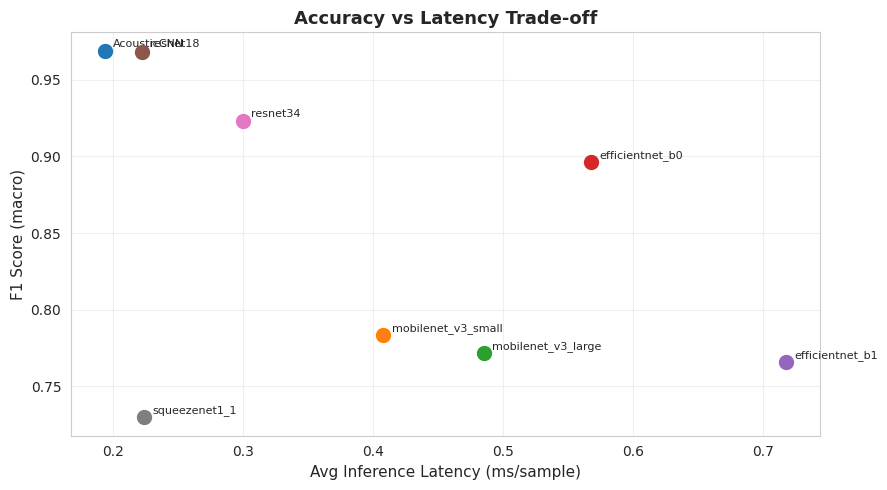

In [14]:
# ── Single file inference ─────────────────────────────────────
def predict_file(model, audio_path: str, cfg: AudioConfig, device=DEVICE) -> dict:
    """Run inference on a single WAV file."""
    model.eval()
    sig, sr = torchaudio.load(audio_path)
    if sr != cfg.sample_rate:
        sig = T.Resample(sr, cfg.sample_rate)(sig)
    if sig.shape[0] > 1:
        sig = sig.mean(dim=0, keepdim=True)

    n = cfg.max_samples
    if sig.shape[1] >= n:
        sig = sig[:, :n]
    else:
        sig = F.pad(sig, (0, n - sig.shape[1]))

    mel = T.MelSpectrogram(sample_rate=cfg.sample_rate, n_fft=cfg.n_fft,
                           hop_length=cfg.hop_length, n_mels=cfg.n_mels)(sig)
    spec = T.AmplitudeToDB(top_db=cfg.top_db)(mel).unsqueeze(0).to(device)  # (1,1,F,T)

    with torch.no_grad():
        logits = model(spec)
        probs  = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    pred_idx = probs.argmax()
    return {
        'predicted_class': CLASS_NAMES[pred_idx],
        'confidence':      float(probs[pred_idx]),
        'all_probs':       {cls: float(p) for cls, p in zip(CLASS_NAMES, probs)}
    }


# ── Batch inference on a folder ───────────────────────────────
def predict_folder(model, folder_path: str, cfg: AudioConfig,
                   device=DEVICE) -> pd.DataFrame:
    """Run inference on all WAV files in a folder."""
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    records = []
    for fname in tqdm(files, desc='Inference'):
        path = os.path.join(folder_path, fname)
        try:
            result = predict_file(model, path, cfg, device)
            records.append({
                'file':             fname,
                'predicted_class':  result['predicted_class'],
                'confidence':       result['confidence'],
                **{f'p_{cls}': result['all_probs'][cls] for cls in CLASS_NAMES}
            })
        except Exception as e:
            print(f'[WARN] {fname}: {e}')
    return pd.DataFrame(records)


# ── Full test-set evaluation with timing ─────────────────────
def test_model(model, loader, model_name: str, device=DEVICE) -> dict:
    """Evaluate on test loader and measure inference time."""
    import time
    model.eval()
    preds, labels = [], []
    times = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            t0 = time.perf_counter()
            out = model(x)
            times.append((time.perf_counter() - t0) / x.size(0))  # per sample
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())

    labels, preds = np.array(labels), np.array(preds)
    results = {
        'model':          model_name,
        'accuracy':       accuracy_score(labels, preds),
        'precision':      precision_score(labels, preds, average='macro', zero_division=0),
        'recall':         recall_score(labels, preds, average='macro', zero_division=0),
        'f1':             f1_score(labels, preds, average='macro', zero_division=0),
        'avg_ms':         np.mean(times) * 1000,   # milliseconds per sample
        'labels':         labels,
        'preds':          preds,
    }

    print(f'\n─── Test Results: {model_name} ───────────────────')
    print(f'  Accuracy  : {results["accuracy"]:.4f}')
    print(f'  Precision : {results["precision"]:.4f}')
    print(f'  Recall    : {results["recall"]:.4f}')
    print(f'  F1 macro  : {results["f1"]:.4f}')
    print(f'  Avg latency: {results["avg_ms"]:.3f} ms/sample')
    print(classification_report(labels, preds, target_names=CLASS_NAMES, zero_division=0))
    plot_confusion(labels, preds, CLASS_NAMES, title=f'{model_name} Test Confusion Matrix')

    return results


# ── Run testing on all models ─────────────────────────────────
# Using val_loader as test set here — swap in a held-out test_loader if you have one
test_results = {}

# AcousticCNN
test_results['AcousticCNN'] = test_model(model_cnn, val_loader, 'AcousticCNN')

# All pretrained backbones — reload best checkpoint before testing
for backbone_name in BACKBONES:
    m = PretrainedAcoustic(num_classes=NUM_CLASSES, backbone_name=backbone_name).to(DEVICE)
    m.load_state_dict(torch.load(f'best_{backbone_name}.pth'))
    test_results[backbone_name] = test_model(m, val_loader, backbone_name)
    del m
    gc.collect()


# ── Final test summary table ──────────────────────────────────
summary = pd.DataFrame([
    {
        'Model':     name,
        'Accuracy':  r['accuracy'],
        'Precision': r['precision'],
        'Recall':    r['recall'],
        'F1':        r['f1'],
        'Latency(ms)': r['avg_ms'],
    }
    for name, r in test_results.items()
]).set_index('Model').sort_values('F1', ascending=False)

print('\n' + '='*60)
print('FINAL TEST SUMMARY')
print('='*60)
print(summary.round(4).to_string())

# Plot latency vs F1 — useful figure for paper
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in test_results.items():
    ax.scatter(r['avg_ms'], r['f1'], s=100, zorder=5)
    ax.annotate(name, (r['avg_ms'], r['f1']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.set_xlabel('Avg Inference Latency (ms/sample)', fontsize=11)
ax.set_ylabel('F1 Score (macro)', fontsize=11)
ax.set_title('Accuracy vs Latency Trade-off', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('latency_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Single file demo ──────────────────────────────────────────
# Uncomment and set path to test on one file:
# result = predict_file(model_cnn, '/path/to/your/file.wav', CFG)
# print(f'Predicted: {result["predicted_class"]}  ({result["confidence"]*100:.1f}%)')
# for cls, prob in sorted(result["all_probs"].items(), key=lambda x: -x[1]):
#     print(f'  {cls:20s}: {prob*100:.2f}%')

In [15]:
import os
import zipfile
from pathlib import Path

def flatten_and_zip_filtered(source_dir, extensions=(".png", ".pth"), zip_filename="selected_files.zip"):
    """
    Recursively collect only files with given extensions from source_dir,
    and add them to a zip file without preserving directory structure.
    Duplicate flat names are resolved by replacing path separators with underscores.
    """
    source_dir = Path(source_dir).resolve()
    zip_path = source_dir / zip_filename

    # Remove existing zip to avoid including itself
    if zip_path.exists():
        os.remove(zip_path)

    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        count = 0
        for root, dirs, files in os.walk(source_dir):
            for file in files:
                # Check extension (case-insensitive)
                if not file.lower().endswith(extensions):
                    continue

                full_path = Path(root) / file
                if full_path == zip_path:
                    continue

                # Relative path from source_dir
                rel_path = full_path.relative_to(source_dir)
                # Flatten: replace separators with underscores
                flat_name = str(rel_path).replace(os.sep, '_')
                zf.write(full_path, arcname=flat_name)
                count += 1

    print(f"✅ Zipped {count} files with extensions {extensions} into: {zip_path}")
    print(f"📦 Download '{zip_filename}' from the file browser.")

# Run the function – only .png and .pth files
flatten_and_zip_filtered("/kaggle/working")

✅ Zipped 34 files with extensions ('.png', '.pth') into: /kaggle/working/selected_files.zip
📦 Download 'selected_files.zip' from the file browser.
